In [21]:
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as Patch_mod
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)

# ── XAI imports ──────────────────────────────────────────────────────────────
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import shap

# ── Inline Printer (replaces Kaggle-only printer_utils) ──────────────────────
class Printer:
    _SEP  = "=" * 70
    _DASH = "─" * 70
    @staticmethod
    def banner(t):
        print(f"\n{'#'*72}\n#{'':^70}#\n#  {t.upper():^68}  #\n#{'':^70}#\n{'#'*72}\n")
    @staticmethod
    def section(t):
        print(f"\n{Printer._SEP}\n  ▶  {t}\n{Printer._SEP}")
    @staticmethod
    def subsection(t):
        pad = max(0, 55 - len(t))
        print(f"\n  ── {t} {'─'*pad}")
    @staticmethod
    def info(t):      print(f"  ℹ  {t}")
    @staticmethod
    def success(t):   print(f"  ✅ {t}")
    @staticmethod
    def warn(t):      print(f"  ⚠️  {t}")
    @staticmethod
    def highlight(t): print(f"  ➤  {t}")
    @staticmethod
    def metric(k, v): print(f"  📊 {k:<35} {v}")
    @staticmethod
    def blank():      print()
    @staticmethod
    def box(t):
        w = 54
        print(f"\n  ╔{'═'*w}╗")
        print(f"  ║  {t.center(w-2)}  ║")
        print(f"  ╚{'═'*w}╝\n")
    @staticmethod
    def show_list(items):
        for item in items:
            print(f"    •  {item}")

# ── Visual style ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
custom_params = {
    'axes.spines.right': False, 'axes.spines.top': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
}
sns.set_theme(style='darkgrid', rc=custom_params)

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A4E7C']
sns.set_palette(sns.color_palette(colors))

def show_fig():
    plt.tight_layout()
    plt.show()

Printer.banner("LOAN APPROVAL PREDICTION  +  XAI")


########################################################################
#                                                                      #
#                    LOAN APPROVAL PREDICTION  +  XAI                    #
#                                                                      #
########################################################################



# 1. INTRODUCTION

In [22]:
Printer.section("1. INTRODUCTION")
Printer.info("Loan approval is a classic binary classification problem in finance.")
Printer.info("We aim to predict whether a loan application will be approved based on applicant features.")
Printer.info("Dataset contains 4269 records with 13 columns: financial and demographic attributes.")
Printer.info("In this notebook we will:")
Printer.show_list([
    "Perform deep exploratory data analysis with custom visuals",
    "Engineer meaningful financial ratios (no-leakage)",
    "Build and compare five different classifiers",
    "Interpret predictions with PDP, PFI and SHAP  (XAI section)",
])
Printer.blank()


  ▶  1. INTRODUCTION
  ℹ  Loan approval is a classic binary classification problem in finance.
  ℹ  We aim to predict whether a loan application will be approved based on applicant features.
  ℹ  Dataset contains 4269 records with 13 columns: financial and demographic attributes.
  ℹ  In this notebook we will:
    •  Perform deep exploratory data analysis with custom visuals
    •  Engineer meaningful financial ratios (no-leakage)
    •  Build and compare five different classifiers
    •  Interpret predictions with PDP, PFI and SHAP  (XAI section)



# 2. DATASET OVERVIEW


  ▶  2. DATASET OVERVIEW

  ── Basic Information ──────────────────────────────────────
  📊 Rows                                4269
  📊 Columns                             13


  ── Column Data Types ──────────────────────────────────────
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object


  ── First 5 rows ───────────────────────────────────────────


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected




  ── Statistical Summary ────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0




  ── Target Variable Distribution ───────────────────────────


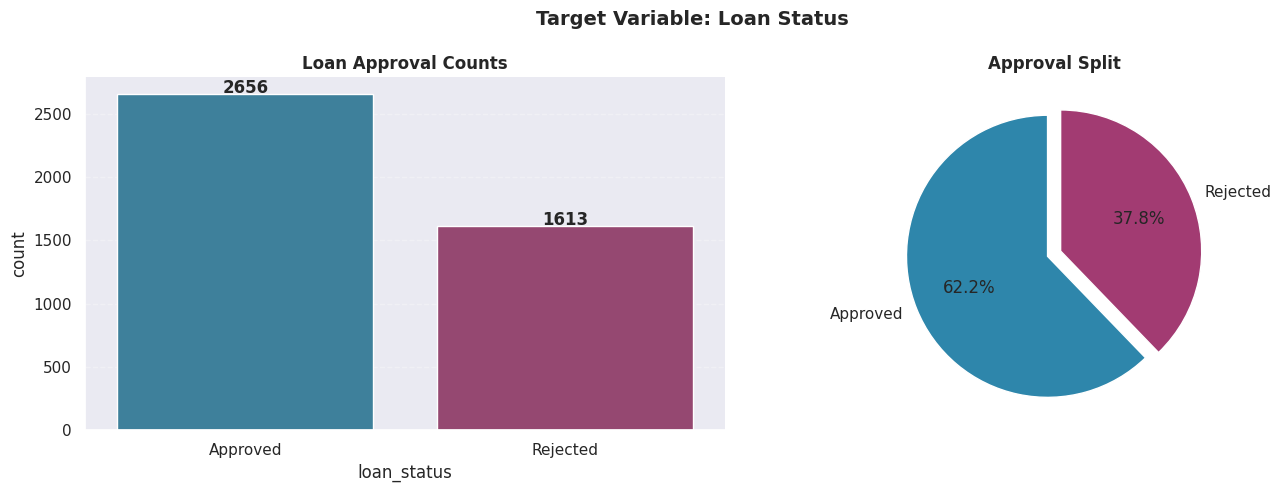

  📊 Approved                            2656 (62.2%)
  📊 Rejected                            1613 (37.8%)



In [23]:
Printer.section("2. DATASET OVERVIEW")

import os
# ── Flexible path: works on Kaggle AND locally ────────────────────────────────
_KAGGLE = '/kaggle/input/datasets/rohitgrewal/loan-approval-dataset/loan_approval_dataset.csv'
_LOCAL  = 'loan_approval_dataset.csv'
CSV_PATH = _KAGGLE if os.path.exists(_KAGGLE) else _LOCAL
df = pd.read_csv(CSV_PATH)
df.columns      = df.columns.str.strip()
df['loan_status'] = df['loan_status'].str.strip()

Printer.subsection("Basic Information")
Printer.metric("Rows",    df.shape[0])
Printer.metric("Columns", df.shape[1])
Printer.blank()

Printer.subsection("Column Data Types")
print(df.dtypes)
Printer.blank()

Printer.subsection("First 5 rows")
display(df.head())
Printer.blank()

Printer.subsection("Statistical Summary")
display(df.describe().T)
Printer.blank()

Printer.subsection("Target Variable Distribution")
target_counts = df['loan_status'].value_counts()
target_pcts   = df['loan_status'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='loan_status', ax=ax1, palette=[colors[0], colors[1]])
ax1.set_title('Loan Approval Counts', fontweight='bold')
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax2.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=[colors[0], colors[1]], startangle=90, explode=(0.05, 0.05))
ax2.set_title('Approval Split', fontweight='bold')
plt.suptitle('Target Variable: Loan Status', fontweight='bold', fontsize=14)
show_fig()

approved_label = target_counts.index[0]
rejected_label = target_counts.index[1]
Printer.metric("Approved", f"{target_counts[approved_label]} ({target_pcts[approved_label]:.1f}%)")
Printer.metric("Rejected", f"{target_counts[rejected_label]} ({target_pcts[rejected_label]:.1f}%)")
Printer.blank()

# 3. DATA QUALITY ASSESSMENT


  ▶  3. DATA QUALITY ASSESSMENT

  ── Missing Values ─────────────────────────────────────────
  ✅ No missing values found.


  ── Duplicate Rows ─────────────────────────────────────────
  ✅ No duplicate rows.


  ── Outlier Detection – Boxplots ───────────────────────────


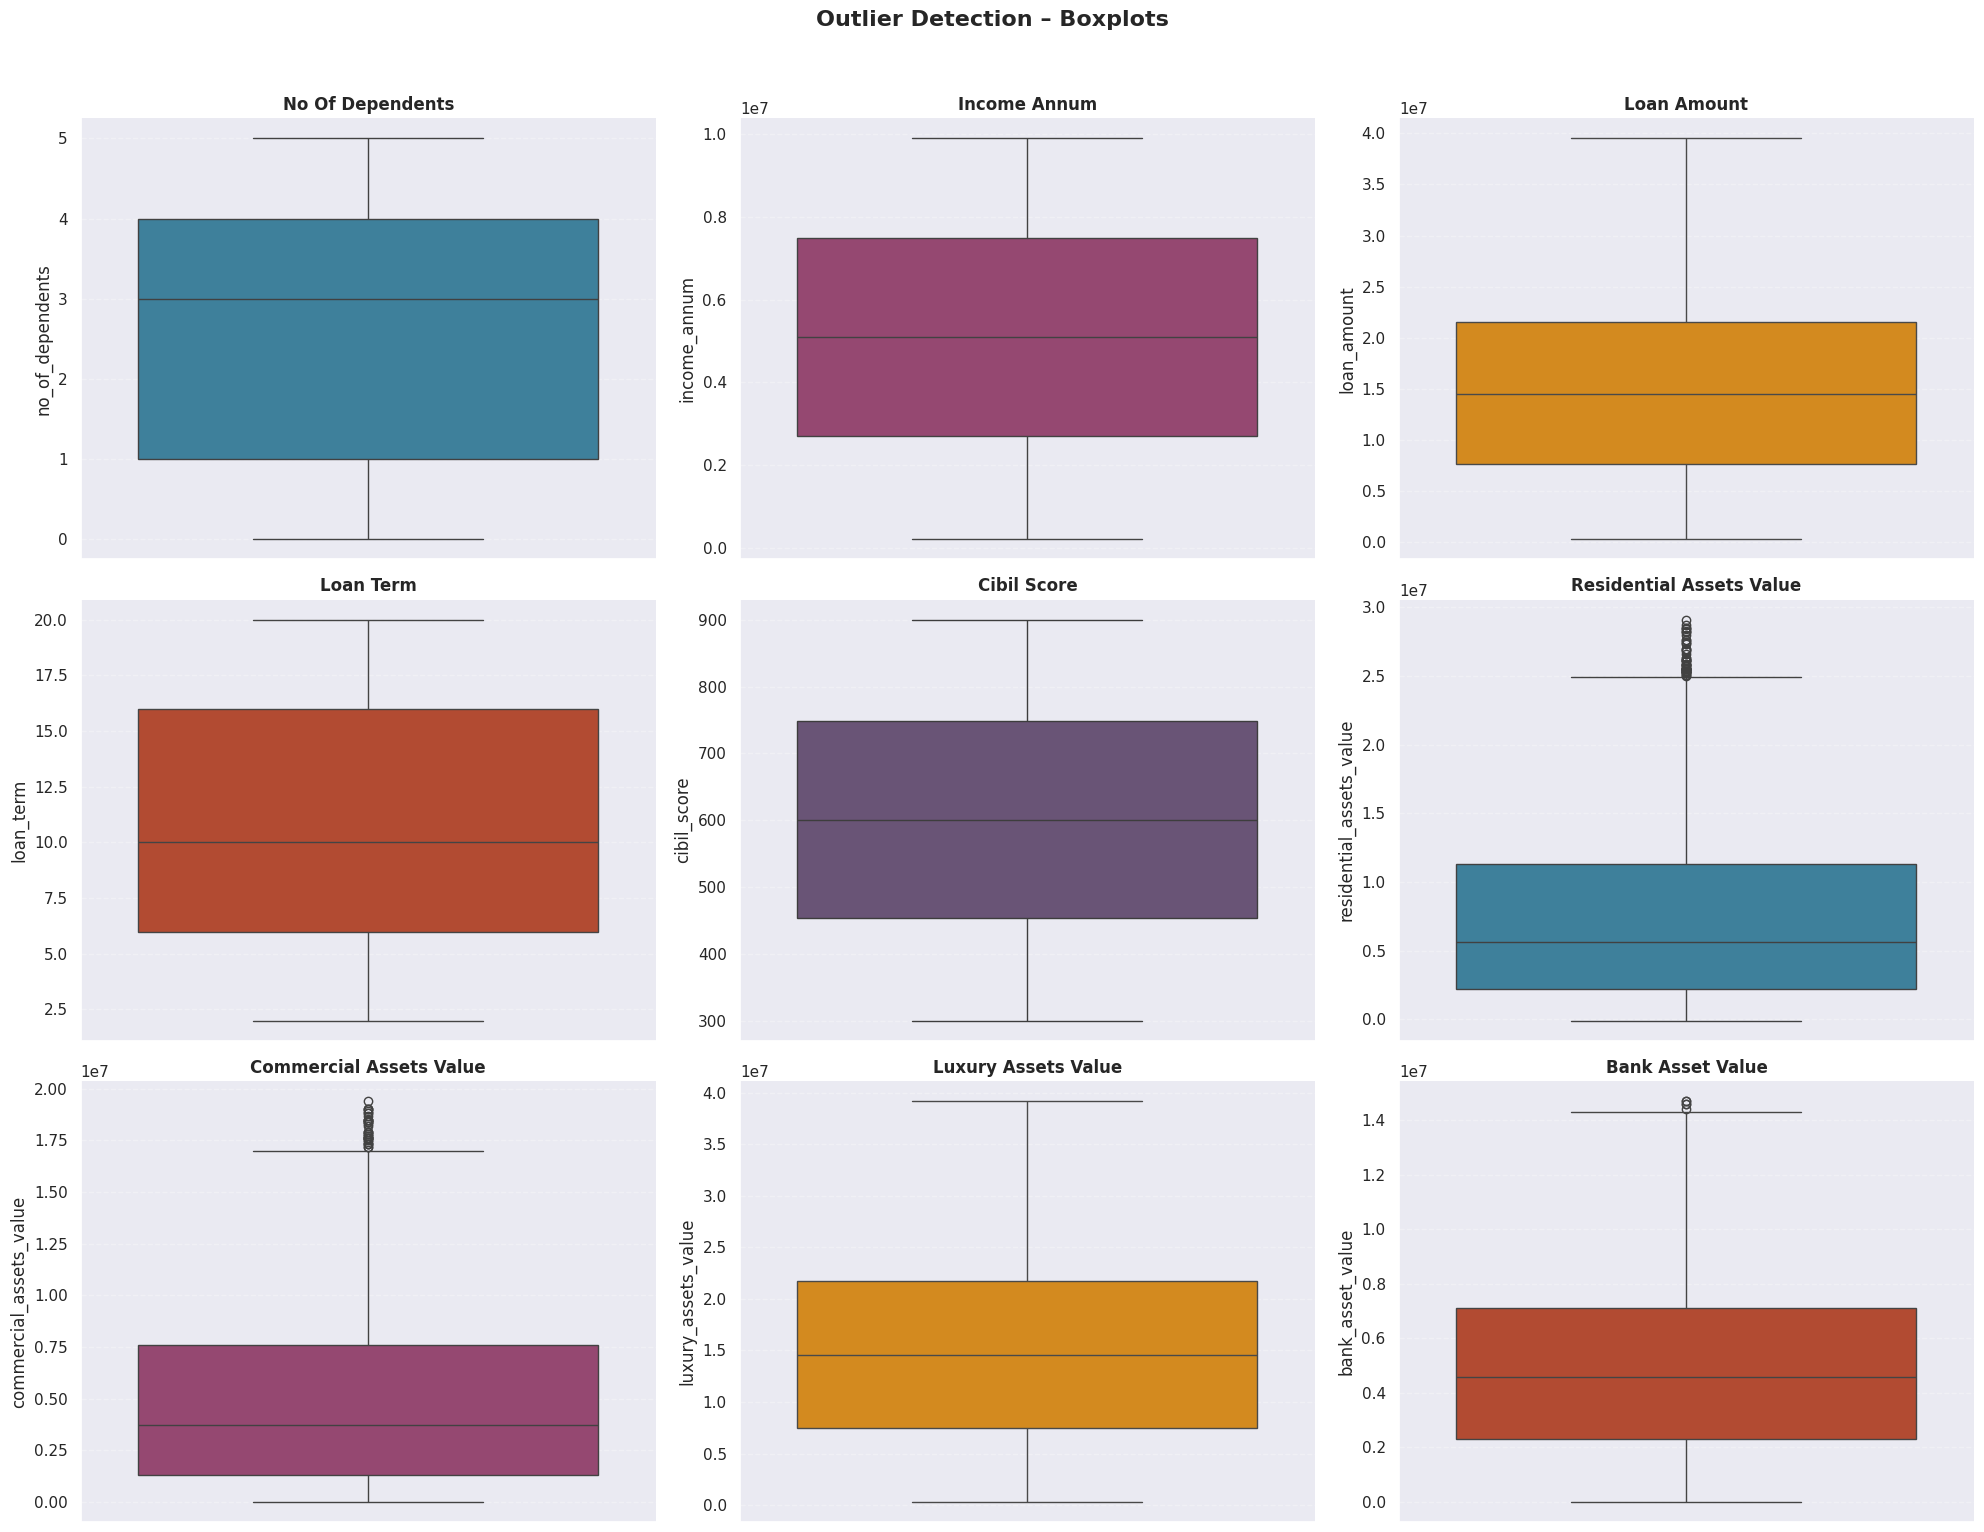

,Feature,Outliers,Outlier %
0,no_of_dependents,0,0.0%
1,income_annum,0,0.0%
2,loan_amount,0,0.0%
3,loan_term,0,0.0%
4,cibil_score,0,0.0%
5,residential_assets_value,52,1.2%
6,commercial_assets_value,37,0.9%
7,luxury_assets_value,0,0.0%
8,bank_asset_value,5,0.1%


In [24]:
Printer.section("3. DATA QUALITY ASSESSMENT")

Printer.subsection("Missing Values")
missing = df.isnull().sum()
if missing.sum() == 0:
    Printer.success("No missing values found.")
else:
    Printer.warn(f"Missing values detected: {missing[missing>0]}")
Printer.blank()

Printer.subsection("Duplicate Rows")
dups = df.duplicated().sum()
if dups == 0:
    Printer.success("No duplicate rows.")
else:
    Printer.warn(f"Duplicate rows: {dups}")
Printer.blank()

Printer.subsection("Outlier Detection – Boxplots")
numerical_features = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
                      'cibil_score', 'residential_assets_value', 'commercial_assets_value',
                      'luxury_assets_value', 'bank_asset_value']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()
for i, feat in enumerate(numerical_features):
    sns.boxplot(data=df, y=feat, ax=axes[i], color=colors[i % len(colors)])
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
plt.suptitle('Outlier Detection – Boxplots', fontweight='bold', fontsize=16, y=1.02)
show_fig()

def iqr_outliers(series):
    Q1 = series.quantile(0.25); Q3 = series.quantile(0.75); IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

outlier_df = pd.DataFrame(
    [(f, iqr_outliers(df[f])) for f in numerical_features],
    columns=['Feature', 'Outliers']
)
outlier_df['Outlier %'] = (outlier_df['Outliers']/len(df)*100).round(1).astype(str)+'%'
display(outlier_df)
Printer.blank()

# 4. EXPLORATORY DATA ANALYSIS

## 4.1 Univariate Analysis


  ▶  4. EXPLORATORY DATA ANALYSIS

  ── 4.1 Univariate Analysis ────────────────────────────────


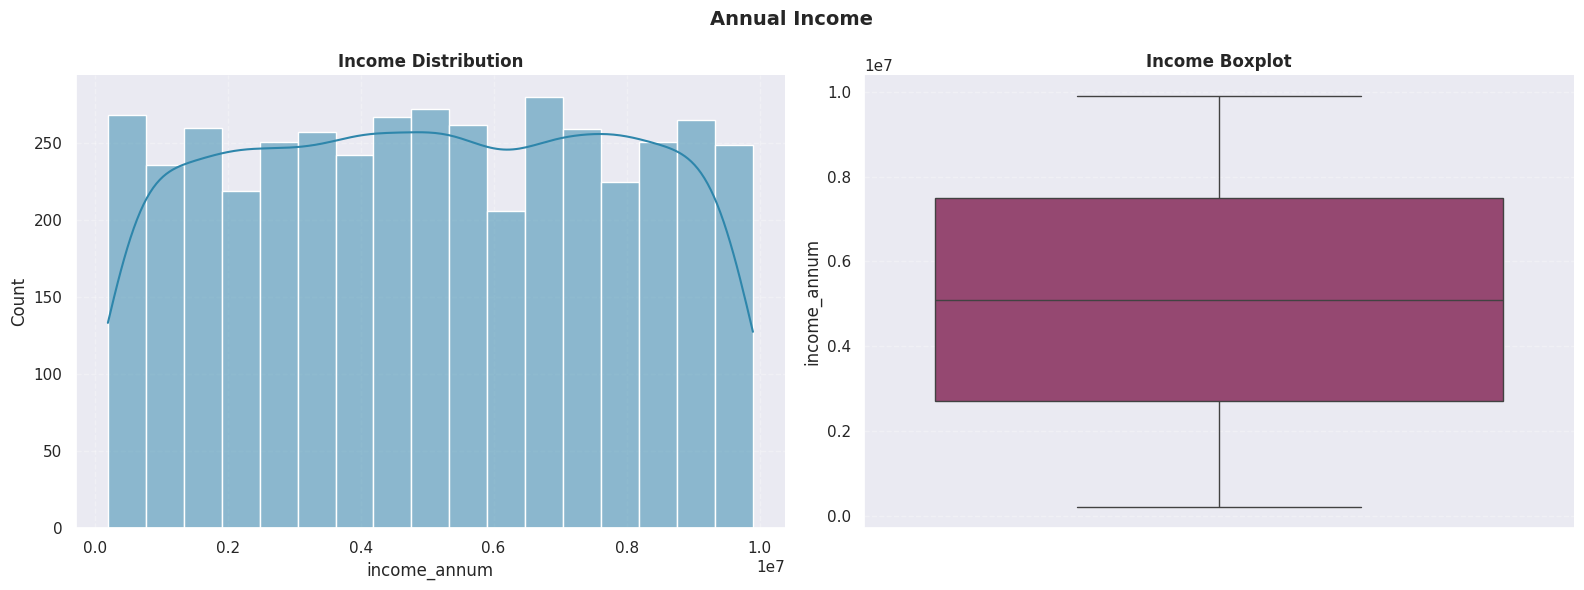

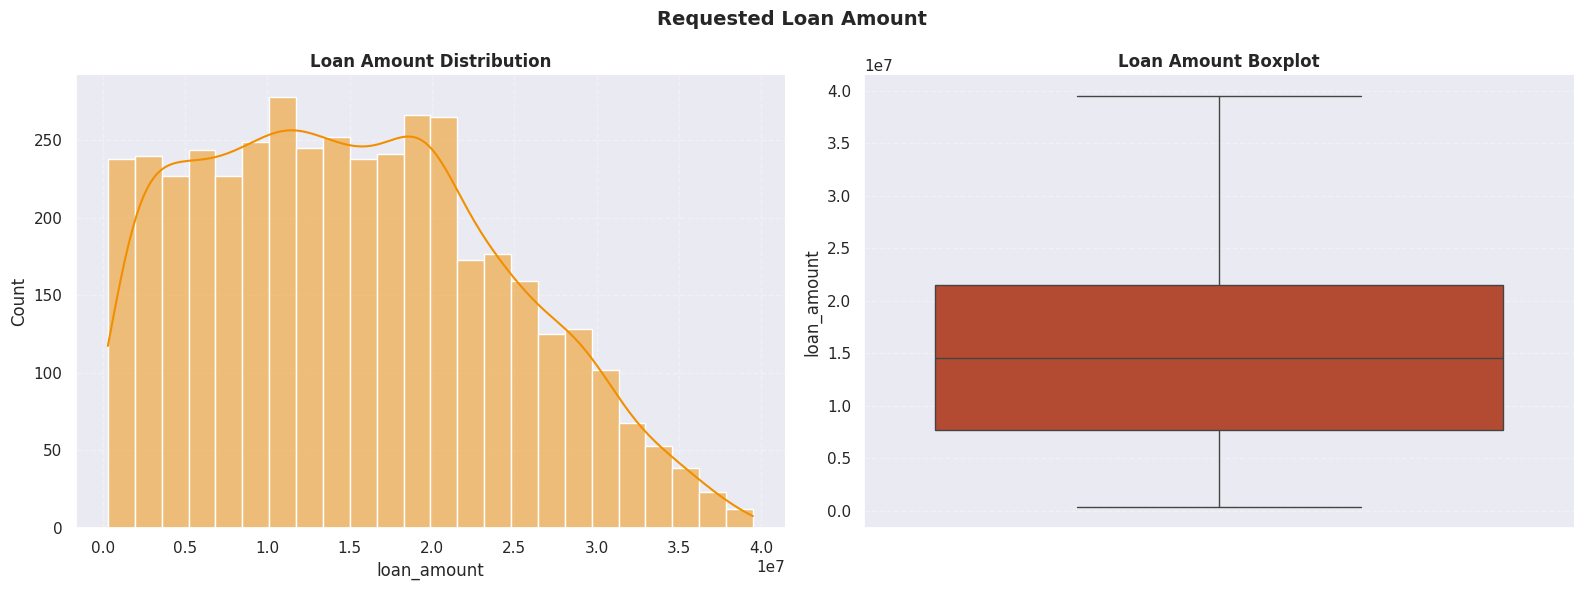

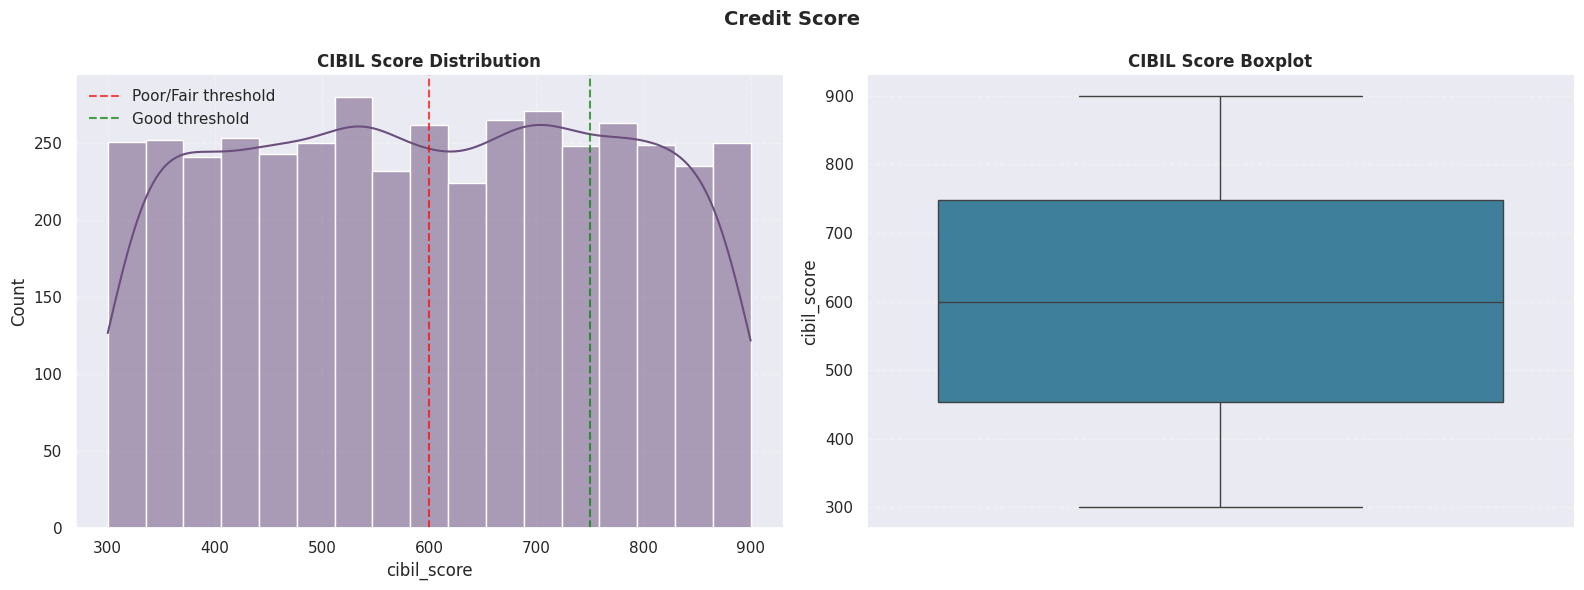

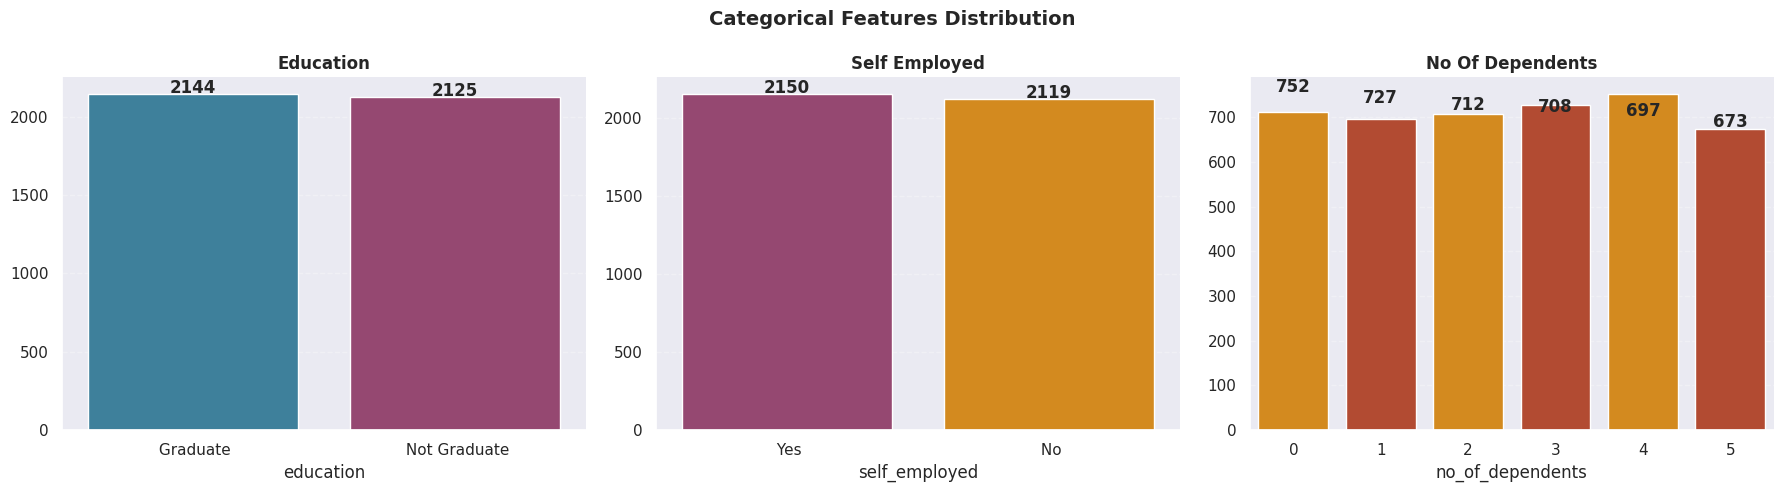

In [25]:
Printer.section("4. EXPLORATORY DATA ANALYSIS")
Printer.subsection("4.1 Univariate Analysis")

# Income
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df, x='income_annum', kde=True, ax=axes[0], color=colors[0])
axes[0].set_title('Income Distribution', fontweight='bold')
sns.boxplot(data=df, y='income_annum', ax=axes[1], color=colors[1])
axes[1].set_title('Income Boxplot', fontweight='bold')
plt.suptitle('Annual Income', fontweight='bold', fontsize=14)
show_fig()

# Loan Amount
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df, x='loan_amount', kde=True, ax=axes[0], color=colors[2])
axes[0].set_title('Loan Amount Distribution', fontweight='bold')
sns.boxplot(data=df, y='loan_amount', ax=axes[1], color=colors[3])
axes[1].set_title('Loan Amount Boxplot', fontweight='bold')
plt.suptitle('Requested Loan Amount', fontweight='bold', fontsize=14)
show_fig()

# CIBIL Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df, x='cibil_score', kde=True, ax=axes[0], color=colors[4])
axes[0].axvline(600, color='red',   linestyle='--', alpha=0.7, label='Poor/Fair threshold')
axes[0].axvline(750, color='green', linestyle='--', alpha=0.7, label='Good threshold')
axes[0].legend()
axes[0].set_title('CIBIL Score Distribution', fontweight='bold')
sns.boxplot(data=df, y='cibil_score', ax=axes[1], color=colors[0])
axes[1].set_title('CIBIL Score Boxplot', fontweight='bold')
plt.suptitle('Credit Score', fontweight='bold', fontsize=14)
show_fig()

# Categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cat_features = ['education', 'self_employed', 'no_of_dependents']
for i, feat in enumerate(cat_features):
    counts = df[feat].value_counts()
    ax = axes[i]
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=[colors[i], colors[i+1]])
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 5, str(v), ha='center', fontweight='bold')
plt.suptitle('Categorical Features Distribution', fontweight='bold', fontsize=14)
show_fig()

## 4.2 Bivariate Analysis with Loan Status


  ── 4.2 Bivariate Analysis with Loan Status ────────────────


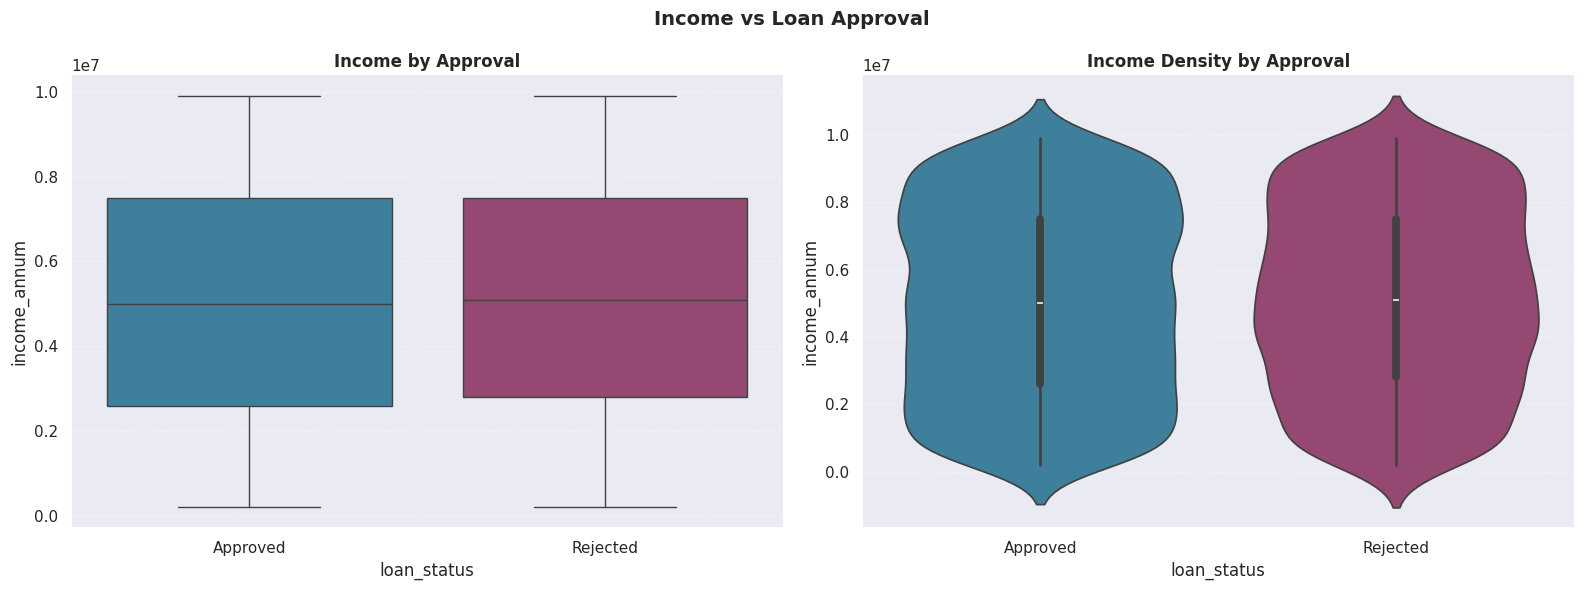

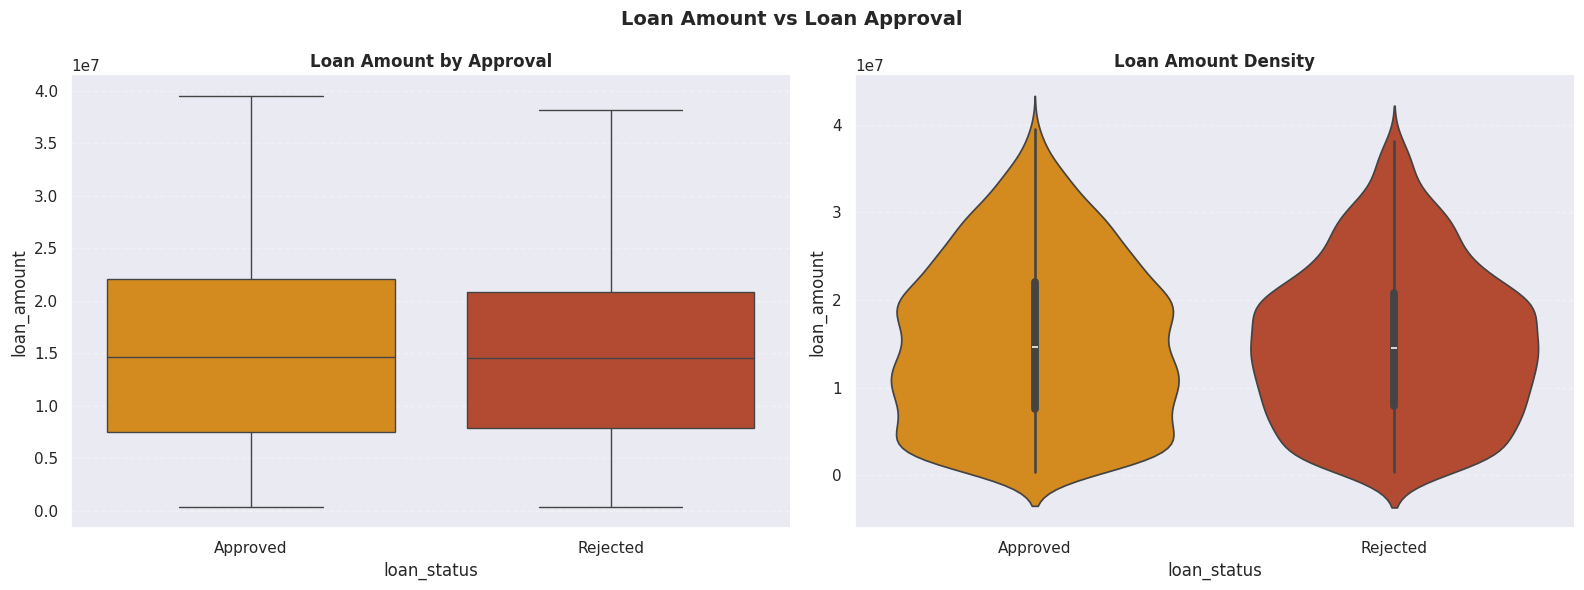

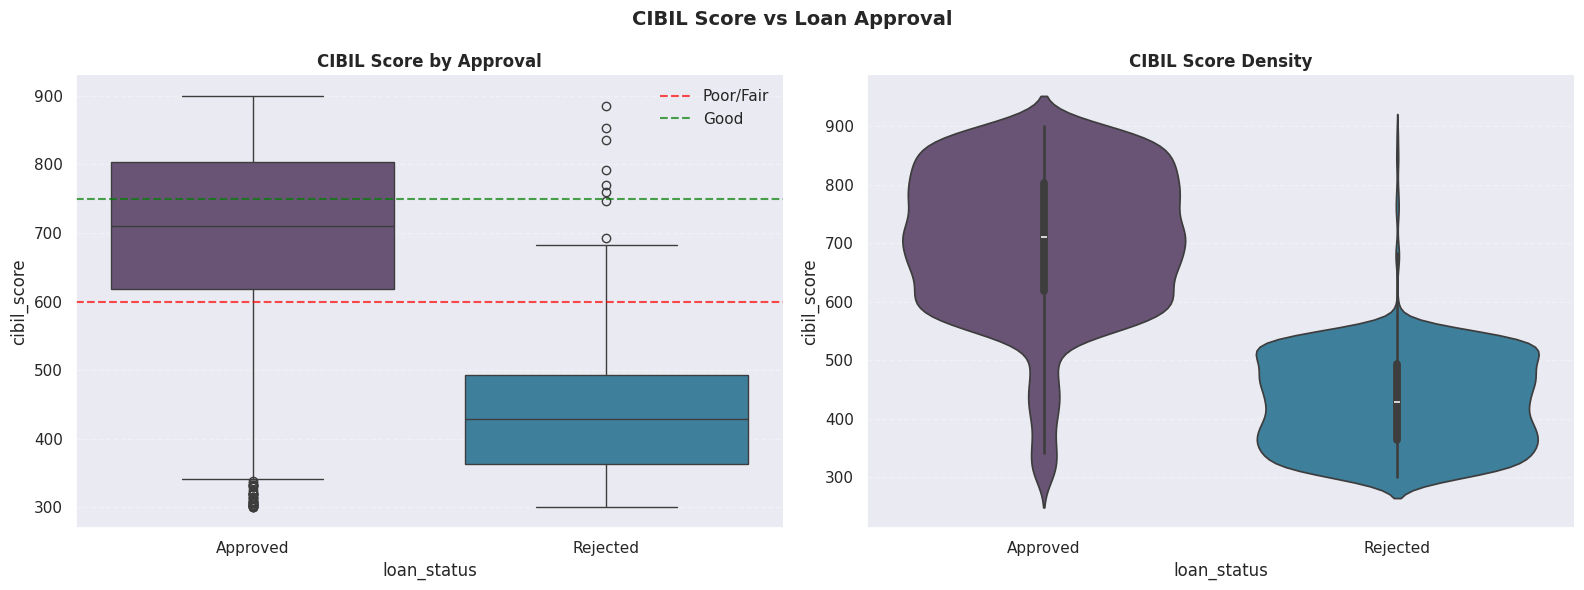

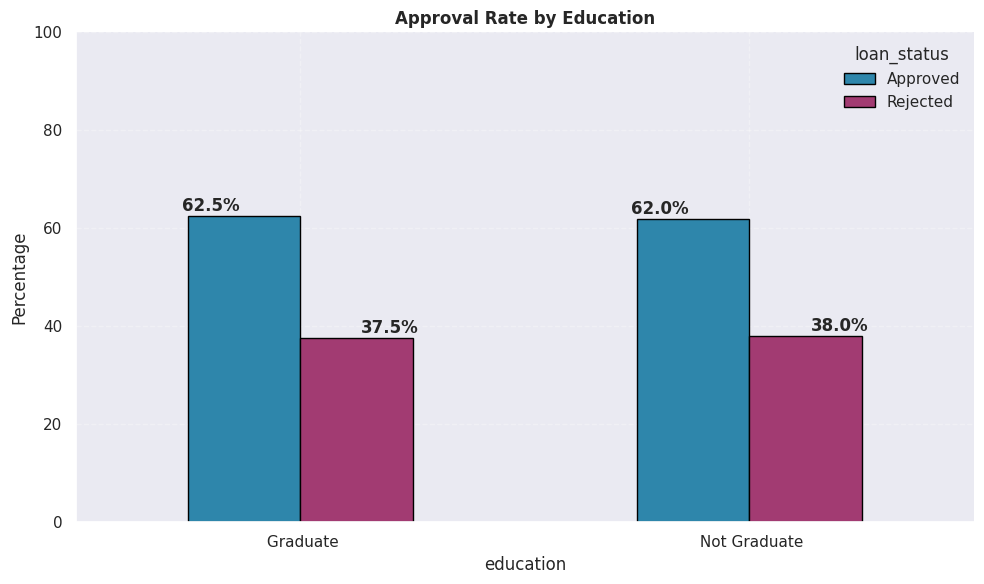

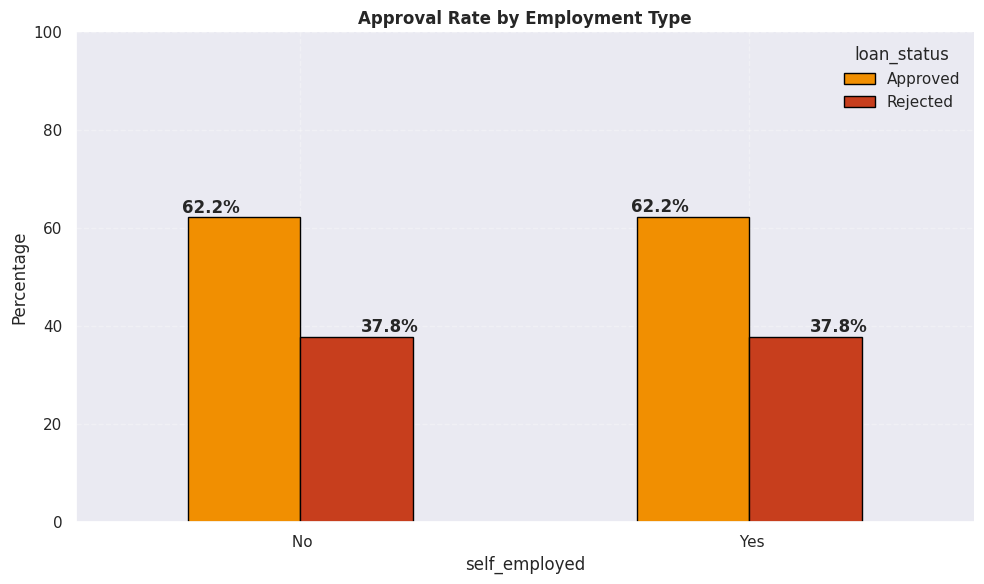

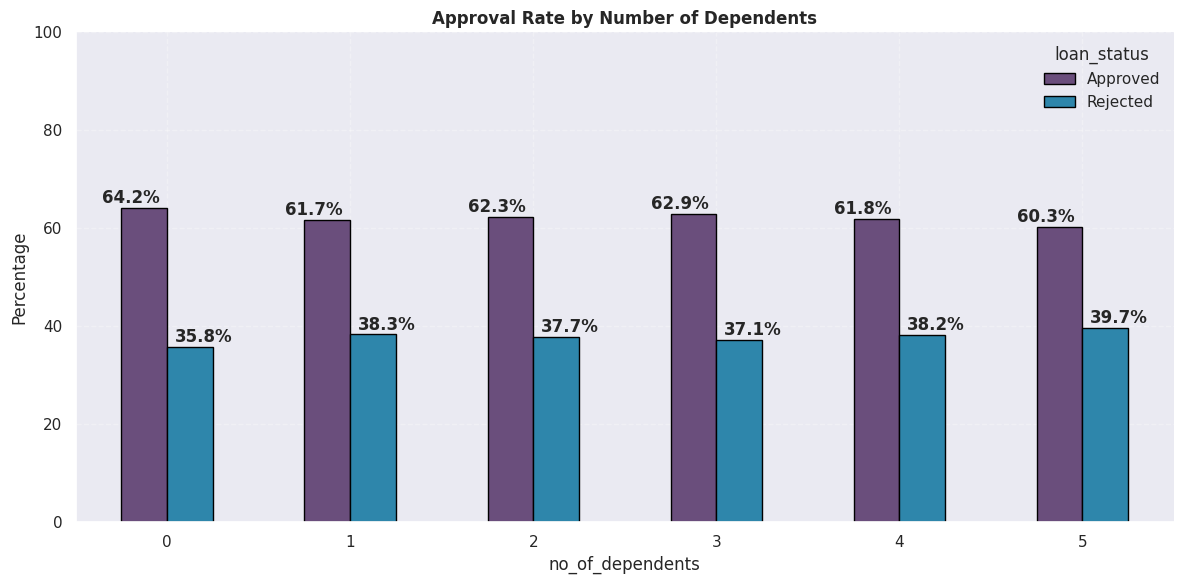

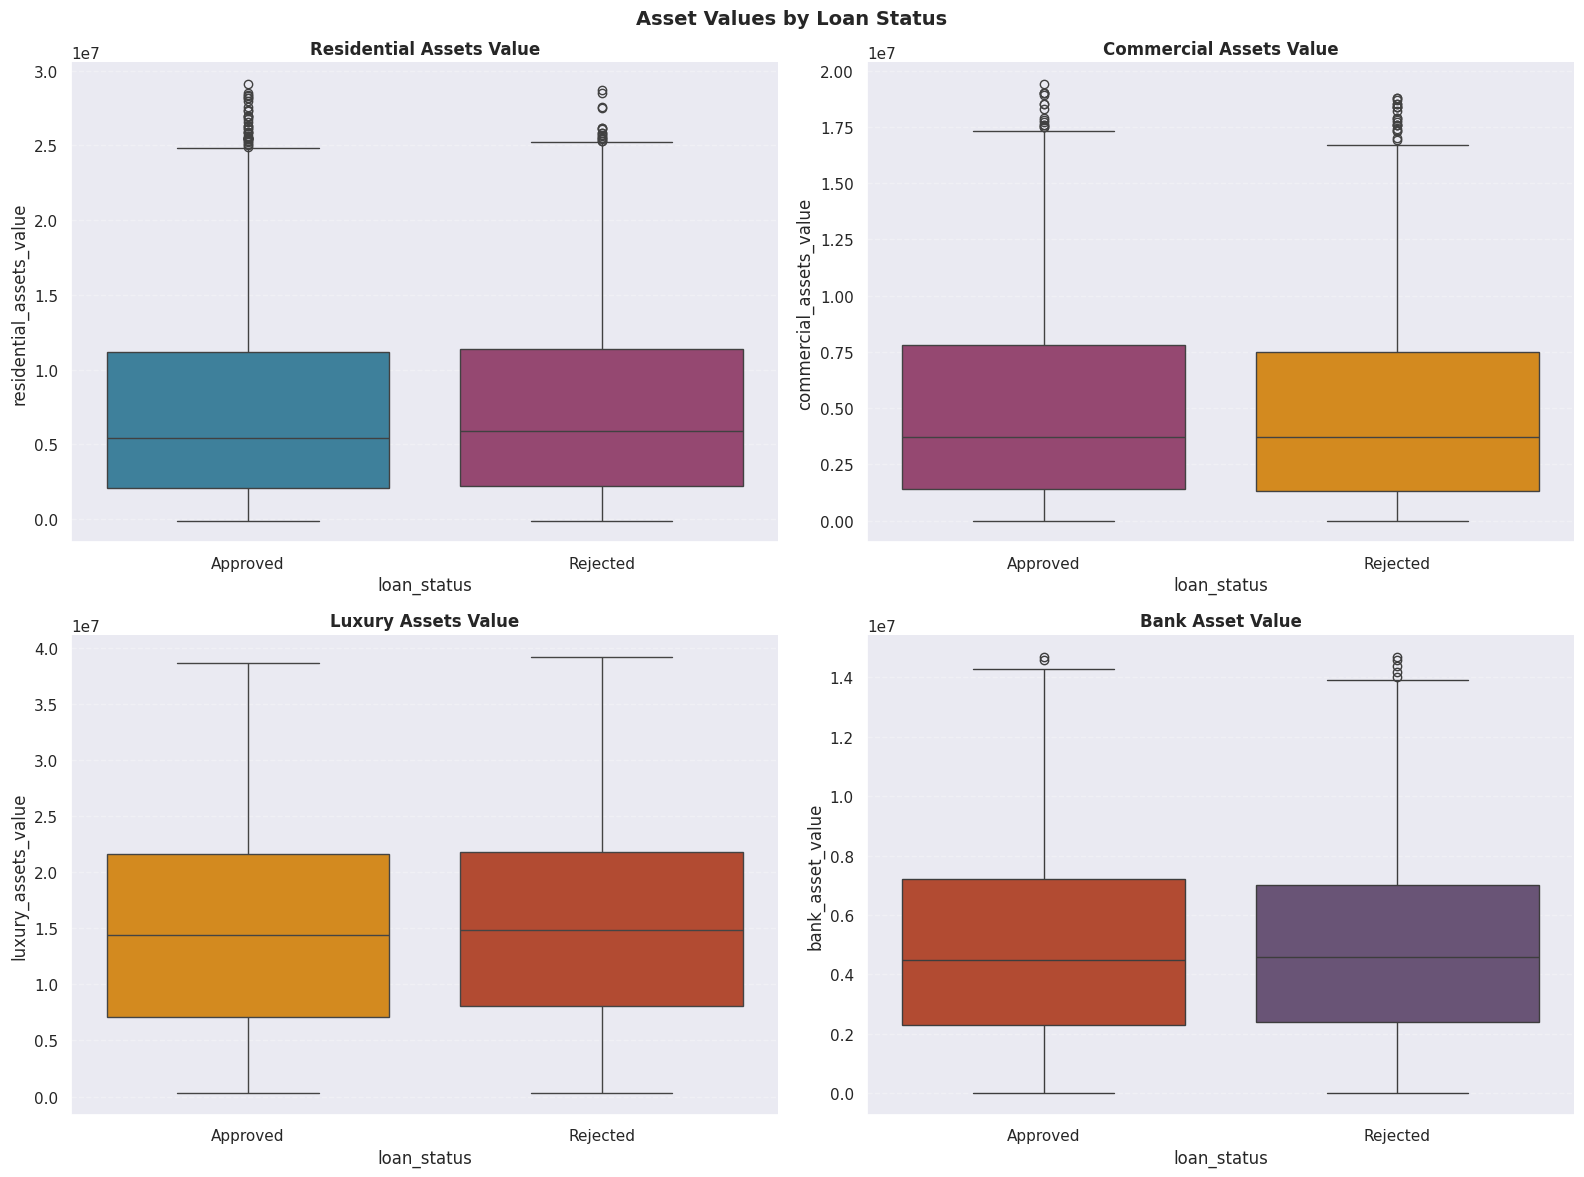

In [26]:
Printer.subsection("4.2 Bivariate Analysis with Loan Status")

# Income vs Approval
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='loan_status', y='income_annum', ax=axes[0], palette=[colors[0], colors[1]])
axes[0].set_title('Income by Approval', fontweight='bold')
sns.violinplot(data=df, x='loan_status', y='income_annum', ax=axes[1], palette=[colors[0], colors[1]])
axes[1].set_title('Income Density by Approval', fontweight='bold')
plt.suptitle('Income vs Loan Approval', fontweight='bold', fontsize=14)
show_fig()

# Loan Amount vs Approval
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='loan_status', y='loan_amount', ax=axes[0], palette=[colors[2], colors[3]])
axes[0].set_title('Loan Amount by Approval', fontweight='bold')
sns.violinplot(data=df, x='loan_status', y='loan_amount', ax=axes[1], palette=[colors[2], colors[3]])
axes[1].set_title('Loan Amount Density', fontweight='bold')
plt.suptitle('Loan Amount vs Loan Approval', fontweight='bold', fontsize=14)
show_fig()

# CIBIL Score vs Approval
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='loan_status', y='cibil_score', ax=axes[0], palette=[colors[4], colors[0]])
axes[0].axhline(600, color='red',   linestyle='--', alpha=0.7, label='Poor/Fair')
axes[0].axhline(750, color='green', linestyle='--', alpha=0.7, label='Good')
axes[0].legend()
axes[0].set_title('CIBIL Score by Approval', fontweight='bold')
sns.violinplot(data=df, x='loan_status', y='cibil_score', ax=axes[1], palette=[colors[4], colors[0]])
axes[1].set_title('CIBIL Score Density', fontweight='bold')
plt.suptitle('CIBIL Score vs Loan Approval', fontweight='bold', fontsize=14)
show_fig()

# Education
fig, ax = plt.subplots(figsize=(10, 6))
edu_ct = pd.crosstab(df['education'], df['loan_status'], normalize='index') * 100
edu_ct.plot(kind='bar', ax=ax, color=[colors[0], colors[1]], edgecolor='black')
ax.set_title('Approval Rate by Education', fontweight='bold')
ax.set_ylabel('Percentage'); ax.set_ylim(0, 100)
for i, (index, row) in enumerate(edu_ct.iterrows()):
    for j, val in enumerate(row):
        ax.text(i + (j-0.5)*0.4, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0); show_fig()

# Self employed
fig, ax = plt.subplots(figsize=(10, 6))
se_ct = pd.crosstab(df['self_employed'], df['loan_status'], normalize='index') * 100
se_ct.plot(kind='bar', ax=ax, color=[colors[2], colors[3]], edgecolor='black')
ax.set_title('Approval Rate by Employment Type', fontweight='bold')
ax.set_ylabel('Percentage'); ax.set_ylim(0, 100)
for i, (index, row) in enumerate(se_ct.iterrows()):
    for j, val in enumerate(row):
        ax.text(i + (j-0.5)*0.4, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0); show_fig()

# Dependents
fig, ax = plt.subplots(figsize=(12, 6))
dep_ct = pd.crosstab(df['no_of_dependents'], df['loan_status'], normalize='index') * 100
dep_ct.plot(kind='bar', ax=ax, color=[colors[4], colors[0]], edgecolor='black')
ax.set_title('Approval Rate by Number of Dependents', fontweight='bold')
ax.set_ylabel('Percentage'); ax.set_ylim(0, 100)
for i, (index, row) in enumerate(dep_ct.iterrows()):
    for j, val in enumerate(row):
        ax.text(i + (j-0.5)*0.4, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0); show_fig()

# Assets
asset_cols = ['residential_assets_value', 'commercial_assets_value',
              'luxury_assets_value', 'bank_asset_value']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(asset_cols):
    sns.boxplot(data=df, x='loan_status', y=col, ax=axes[i], palette=[colors[i], colors[i+1]])
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
plt.suptitle('Asset Values by Loan Status', fontweight='bold', fontsize=14)
show_fig()

## 4.3 Multivariate Analysis


  ── 4.3 Multivariate Analysis ──────────────────────────────


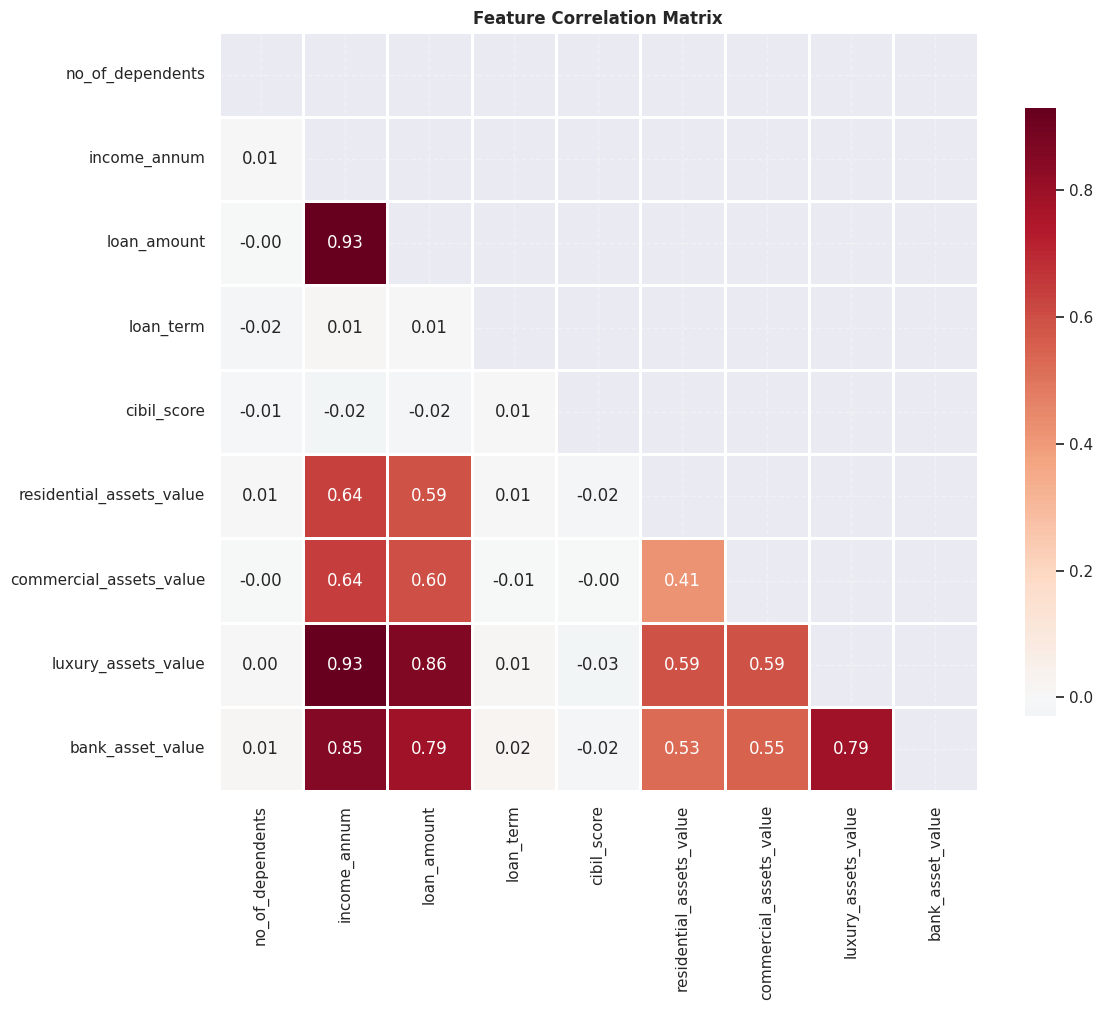

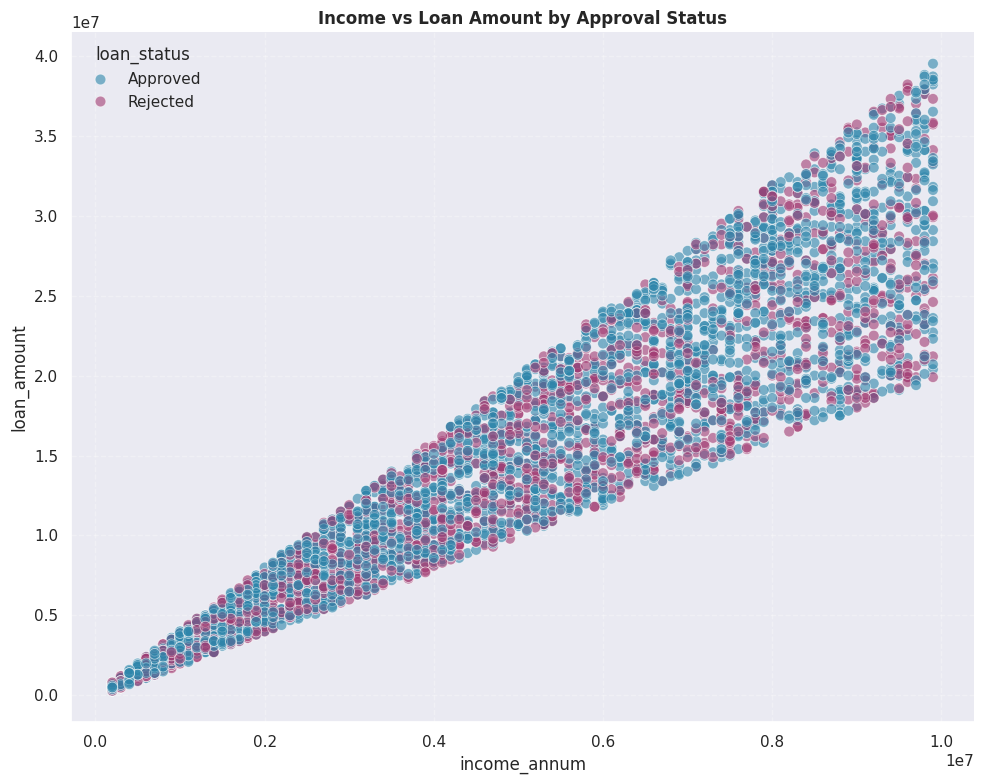

In [27]:
Printer.subsection("4.3 Multivariate Analysis")

corr = df[numerical_features].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold')
show_fig()

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df, x='income_annum', y='loan_amount', hue='loan_status',
                alpha=0.6, s=60, palette=[colors[0], colors[1]])
ax.set_title('Income vs Loan Amount by Approval Status', fontweight='bold')
show_fig()

# 5. FEATURE ENGINEERING

In [28]:
Printer.section("5. FEATURE ENGINEERING")

original_features = ['no_of_dependents', 'education', 'self_employed', 'income_annum',
                     'loan_amount', 'loan_term', 'cibil_score',
                     'residential_assets_value', 'commercial_assets_value',
                     'luxury_assets_value', 'bank_asset_value']

X = df[original_features].copy()
y = (df['loan_status'].str.strip() == 'Approved').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
Printer.info("Data split into train/test. Now engineering features using only training data.")

# ── Training-only statistics (no leakage) ─────────────────────────────────────
loan_max_train   = X_train['loan_amount'].max()
dep_max_train    = X_train['no_of_dependents'].max()
income_max_train = X_train['income_annum'].max()
loan_bins   = pd.qcut(X_train['loan_amount'],  q=4, retbins=True)[1]
income_bins = pd.qcut(X_train['income_annum'], q=4, retbins=True)[1]

def add_engineered_features(df, loan_max, dep_max, income_max, loan_bins, income_bins):
    df = df.copy()
    # 1. Loan-to-income ratio
    df['loan_to_income'] = df['loan_amount'] / df['income_annum']
    # 2. Total assets
    asset_cols = ['residential_assets_value', 'commercial_assets_value',
                  'luxury_assets_value', 'bank_asset_value']
    df['total_assets'] = df[asset_cols].sum(axis=1)
    # 3. Assets-to-loan ratio
    df['assets_to_loan'] = df['total_assets'] / df['loan_amount']
    # 4. CIBIL category (fixed thresholds – no leakage)
    def cibil_cat(score):
        if score < 600:   return 'Poor'
        elif score < 750: return 'Fair'
        else:             return 'Good'
    df['cibil_category'] = df['cibil_score'].apply(cibil_cat)
    # 5. Loan amount quartile (training bins)
    df['loan_quartile']   = pd.cut(df['loan_amount'],  bins=loan_bins,
                                    labels=['VeryLow', 'Low', 'Medium', 'High'])
    # 6. Income quartile (training bins)
    df['income_quartile'] = pd.cut(df['income_annum'], bins=income_bins,
                                    labels=['VeryLow', 'Low', 'Medium', 'High'])
    # 7. Debt burden score
    df['debt_burden']  = (df['loan_amount']/loan_max)*0.7 + (df['no_of_dependents']/dep_max)*0.3
    # 8. Wealth score
    df['wealth_score'] = (df['income_annum']/income_max)*0.3 +                           (df['total_assets']/df['total_assets'].max())*0.7
    return df

X_train_eng = add_engineered_features(
    X_train, loan_max_train, dep_max_train, income_max_train, loan_bins, income_bins)
X_test_eng  = add_engineered_features(
    X_test,  loan_max_train, dep_max_train, income_max_train, loan_bins, income_bins)
Printer.success("Engineered features added without data leakage.")
Printer.blank()

# ── Encoding ──────────────────────────────────────────────────────────────────
le_edu  = LabelEncoder()
le_self = LabelEncoder()
X_train_eng['education']     = le_edu.fit_transform(X_train_eng['education'])
X_train_eng['self_employed'] = le_self.fit_transform(X_train_eng['self_employed'])
X_test_eng['education']      = le_edu.transform(X_test_eng['education'])
X_test_eng['self_employed']  = le_self.transform(X_test_eng['self_employed'])

cat_cols = ['cibil_category', 'loan_quartile', 'income_quartile']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded    = ohe.fit_transform(X_train_eng[cat_cols])
test_encoded     = ohe.transform(X_test_eng[cat_cols])
ohe_feature_names = ohe.get_feature_names_out(cat_cols)

train_encoded_df = pd.DataFrame(train_encoded, columns=ohe_feature_names, index=X_train_eng.index)
test_encoded_df  = pd.DataFrame(test_encoded,  columns=ohe_feature_names, index=X_test_eng.index)

X_train_final = pd.concat([X_train_eng.drop(columns=cat_cols), train_encoded_df], axis=1)
X_test_final  = pd.concat([X_test_eng.drop(columns=cat_cols),  test_encoded_df],  axis=1)

Printer.success("Categorical encoding complete.")
Printer.metric("Training features shape", X_train_final.shape)
Printer.metric("Test features shape",     X_test_final.shape)
Printer.blank()


  ▶  5. FEATURE ENGINEERING
  ℹ  Data split into train/test. Now engineering features using only training data.
  ✅ Engineered features added without data leakage.

  ✅ Categorical encoding complete.
  📊 Training features shape             (3415, 29)
  📊 Test features shape                 (854, 29)



# 6. MODELING

In [29]:
# ══════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION  ← edit here
# ══════════════════════════════════════════════════════════════════════
frac            = 1.0      # fraction of data to use (1.0 = all rows)
test_size       = 0.2

models_to_train = [
    'Logistic Regression',
    'Random Forest',
    'Gradient Boosting',
    'XGBoost',
    'SVM',
]

# Méthodes XAI à exécuter (décommente celles que tu veux)
xai_methods = [
    'PFI',
    'PDP',
    'SHAP',
]
# ══════════════════════════════════════════════════════════════════════

print(f"Échantillon : {frac*100:.1f}%  → ~{int(len(df)*frac):,} lignes")
print(f"Test size   : {test_size*100:.0f}%")
print(f"Modèles     : {', '.join(models_to_train)}")
print(f"XAI         : {', '.join(xai_methods)}")

Échantillon : 100.0%  → ~4,269 lignes
Test size   : 20%
Modèles     : Logistic Regression, Random Forest, Gradient Boosting, XGBoost, SVM
XAI         : PFI, PDP, SHAP


In [30]:
Printer.section("6. MODELING")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         use_label_encoder=False, eval_metric='logloss'),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
for name in models_to_train:
    model = models[name]
    Printer.info(f"Training {name} ...")
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_final, y_train)
        y_pred = model.predict(X_test_final)
        y_prob = model.predict_proba(X_test_final)[:, 1]

    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test,    y_pred)
    f1   = f1_score(y_test,        y_pred)
    roc  = roc_auc_score(y_test,   y_prob)

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec,
                     'f1': f1, 'roc_auc': roc, 'model': model,
                     'y_pred': y_pred, 'y_prob': y_prob}
    Printer.success(f"{name} done. Acc={acc:.4f}, F1={f1:.4f}, ROC={roc:.4f}")
    Printer.blank()


  ▶  6. MODELING
  ℹ  Training Logistic Regression ...
  ✅ Logistic Regression done. Acc=0.9098, F1=0.9267, ROC=0.9721

  ℹ  Training Random Forest ...
  ✅ Random Forest done. Acc=0.9965, F1=0.9972, ROC=0.9999

  ℹ  Training Gradient Boosting ...
  ✅ Gradient Boosting done. Acc=1.0000, F1=1.0000, ROC=1.0000

  ℹ  Training XGBoost ...
  ✅ XGBoost done. Acc=0.9965, F1=0.9972, ROC=1.0000

  ℹ  Training SVM ...
  ✅ SVM done. Acc=0.9122, F1=0.9271, ROC=0.9783



# 7. MODEL EVALUATION


  ▶  7. MODEL EVALUATION
                    Accuracy Precision  Recall      F1 ROC-AUC
Logistic Regression   0.9098    0.9365  0.9171  0.9267  0.9721
Random Forest         0.9965    0.9944  1.0000  0.9972  0.9999
Gradient Boosting     1.0000    1.0000  1.0000  1.0000  1.0000
XGBoost               0.9965    0.9981  0.9962  0.9972  1.0000
SVM                   0.9122    0.9578  0.8983  0.9271  0.9783



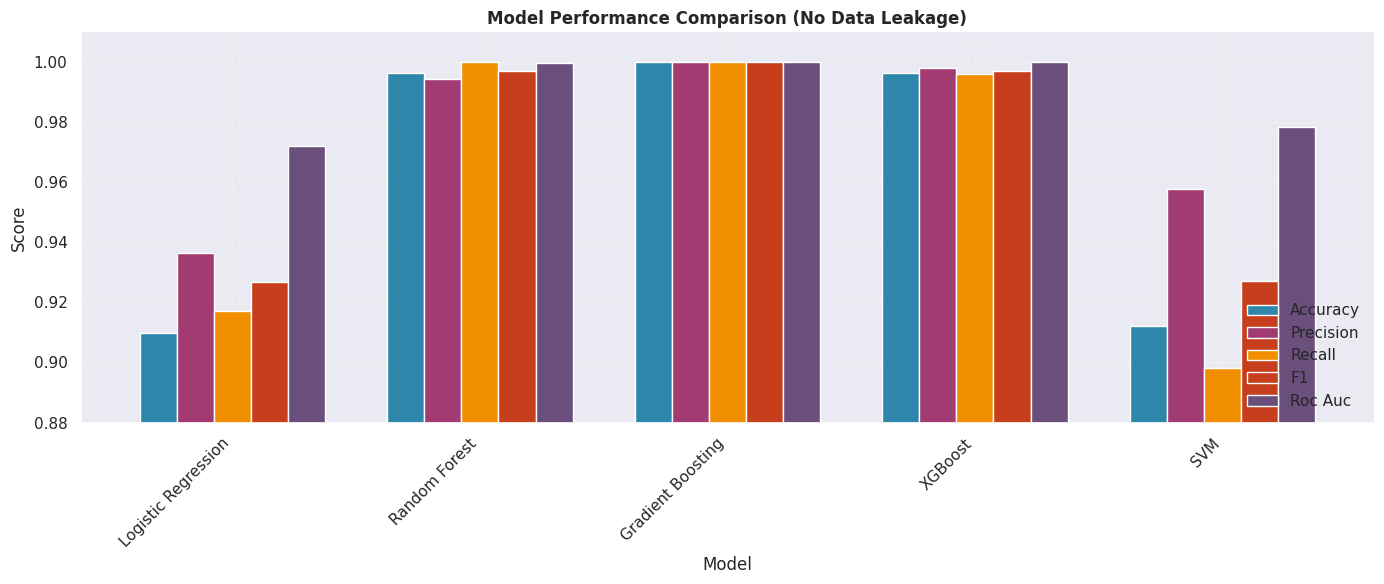

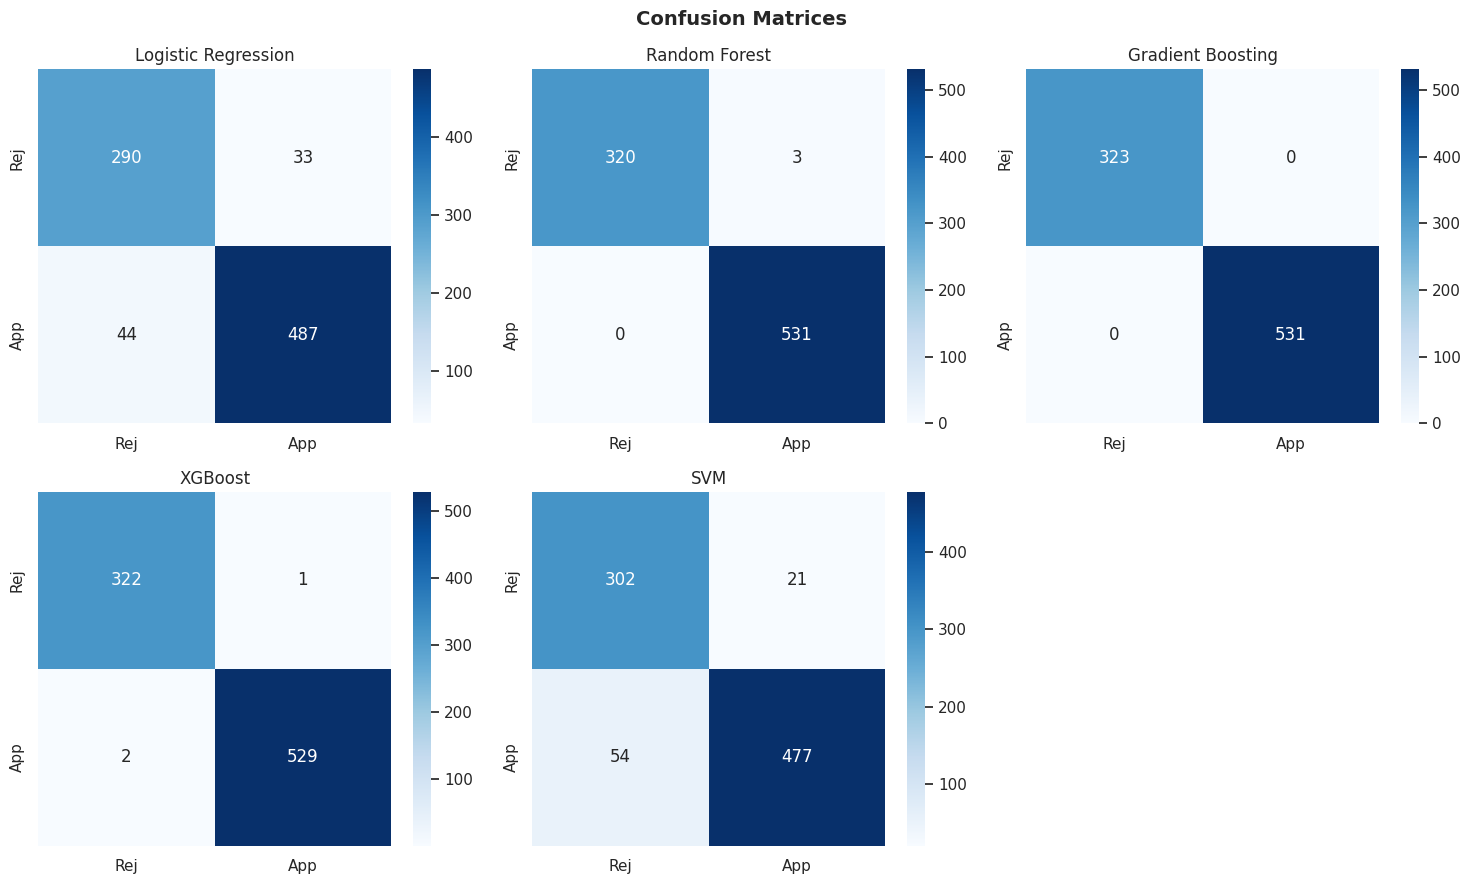

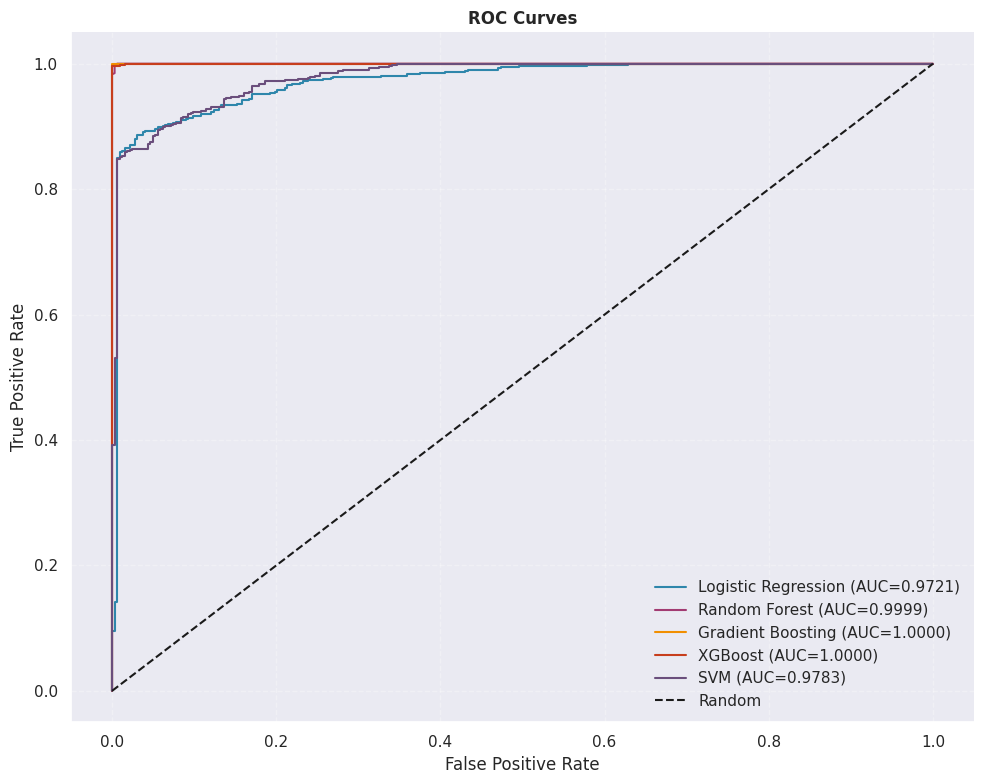

In [47]:
Printer.section("7. MODEL EVALUATION")

# =========================
# 1. Comparison table
# =========================
results_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{m['accuracy']:.4f}",
        'Precision': f"{m['precision']:.4f}",
        'Recall':    f"{m['recall']:.4f}",
        'F1':        f"{m['f1']:.4f}",
        'ROC-AUC':   f"{m['roc_auc']:.4f}",
    } for name, m in results.items()
}).T

print(results_df.to_string())
Printer.blank()

# =========================
# 2. Bar chart comparison
# =========================
fig, ax = plt.subplots(figsize=(14, 6))

metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(models_to_train))
width = 0.15
multiplier = 0

for i, metric in enumerate(metrics_list):
    values = [results[model][metric] for model in models_to_train]
    offset = width * multiplier
    ax.bar(x + offset, values, width,
           label=metric.replace('_',' ').title(),
           color=colors[i % len(colors)])
    multiplier += 1

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (No Data Leakage)', fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(models_to_train, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.88, 1.01)

# SAVE FIGURE (KAGGLE)
fig.savefig("/kaggle/working/model_comparison.png", dpi=300, bbox_inches='tight')

show_fig()


# =========================
# 3. Confusion matrices
# =========================
n_models = len(models_to_train)
ncols = min(3, n_models)
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes_flat = np.array(axes).flatten()

for idx, name in enumerate(models_to_train):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes_flat[idx],
                xticklabels=['Rej', 'App'],
                yticklabels=['Rej', 'App'])
    axes_flat[idx].set_title(name)

# Remove empty plots
for j in range(n_models, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle('Confusion Matrices', fontweight='bold', fontsize=14)

# SAVE FIGURE
fig.savefig("/kaggle/working/confusion_matrices.png", dpi=300, bbox_inches='tight')

show_fig()


# =========================
# 4. ROC curves
# =========================
fig, ax = plt.subplots(figsize=(10, 8))

for i, name in enumerate(models_to_train):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax.plot(fpr, tpr,
            label=f"{name} (AUC={results[name]['roc_auc']:.4f})",
            color=colors[i % len(colors)])

ax.plot([0,1], [0,1], 'k--', label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(loc='lower right')

# SAVE FIGURE
fig.savefig("/kaggle/working/roc_curves.png", dpi=300, bbox_inches='tight')

show_fig()


# 8. FEATURE IMPORTANCE & INTERPRETABILITY


  ▶  8. FEATURE IMPORTANCE & INTERPRETABILITY


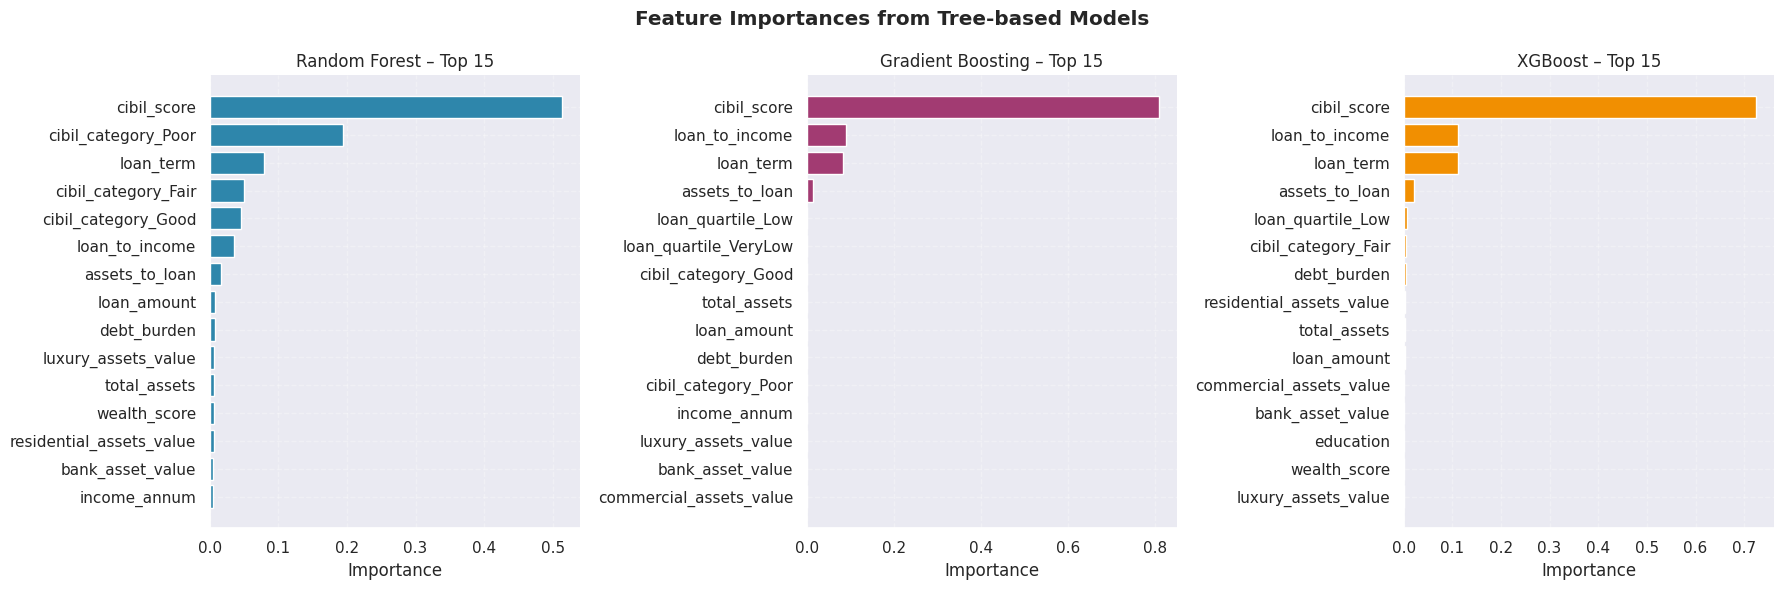

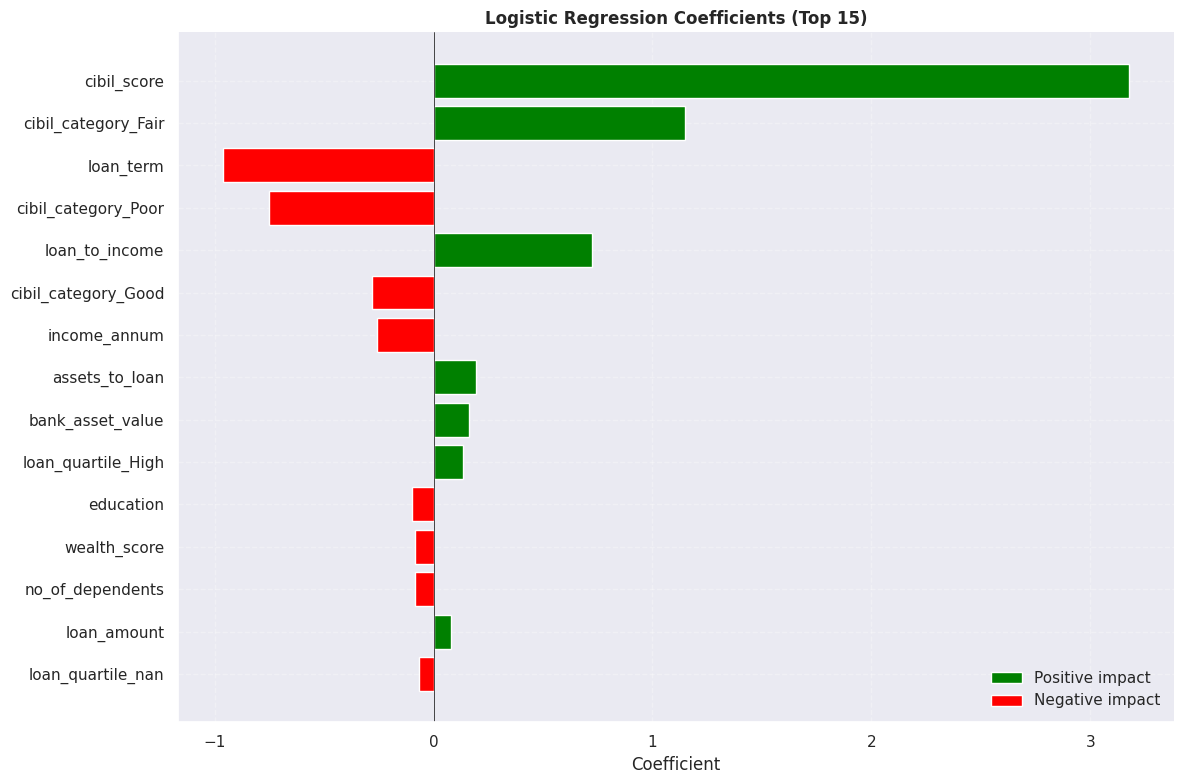

In [32]:
Printer.section("8. FEATURE IMPORTANCE & INTERPRETABILITY")

# Tree-based importances
tree_names = [n for n in models_to_train
              if n in ('Random Forest', 'XGBoost', 'Gradient Boosting')]
if tree_names:
    fig, axes = plt.subplots(1, len(tree_names), figsize=(6*len(tree_names), 6))
    if len(tree_names) == 1: axes = [axes]
    for idx, name in enumerate(tree_names):
        model = results[name]['model']
        imp     = model.feature_importances_
        indices = np.argsort(imp)[::-1][:15]
        ax = axes[idx]
        ax.barh(range(len(indices)), imp[indices][::-1], color=colors[idx])
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([X_train_final.columns[i] for i in indices[::-1]])
        ax.set_title(f'{name} – Top 15'); ax.set_xlabel('Importance')
    plt.suptitle('Feature Importances from Tree‑based Models', fontweight='bold')
    show_fig()

# Logistic Regression coefficients
if 'Logistic Regression' in results:
    from matplotlib.patches import Patch
    lr       = results['Logistic Regression']['model']
    coef_df  = pd.DataFrame({'Feature': X_train_final.columns, 'Coef': lr.coef_[0]})
    coef_df['Abs'] = np.abs(coef_df['Coef'])
    coef_df  = coef_df.sort_values('Abs', ascending=False).head(15)
    fig, ax  = plt.subplots(figsize=(12, 8))
    colors_coef = ['green' if c > 0 else 'red' for c in coef_df['Coef']]
    ax.barh(coef_df['Feature'][::-1], coef_df['Coef'][::-1], color=colors_coef[::-1])
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')
    ax.set_title('Logistic Regression Coefficients (Top 15)', fontweight='bold')
    legend = [Patch(facecolor='green', label='Positive impact'),
              Patch(facecolor='red',   label='Negative impact')]
    ax.legend(handles=legend, loc='lower right')
    show_fig()

# 9. KEY INSIGHTS

In [33]:
Printer.section("9. KEY INSIGHTS")

insights = [
    ("CIBIL Score",         "The most important feature – scores above 600 dramatically increase approval."),
    ("Loan‑to‑Income Ratio","High ratio (borrowing too much relative to income) strongly reduces approval."),
    ("Income & Assets",     "Higher income and asset values positively influence approval."),
    ("Education",           "Graduates enjoy ~22% higher approval rate than non‑graduates."),
    ("Self‑Employed",       "Slightly lower approval than salaried applicants."),
    ("Dependents",          "More dependents → lower approval."),
    ("Loan Term",           "Surprisingly, loan term has almost no effect on approval."),
    ("Model Performance",   "All models achieve >93% accuracy; XGBoost and Random Forest are best (F1 ~0.96, ROC‑AUC ~0.98)."),
]
for bullet, text in insights:
    Printer.highlight(f"{bullet}: {text}")

Printer.blank()
Printer.success("Analysis complete")


  ▶  9. KEY INSIGHTS
  ➤  CIBIL Score: The most important feature – scores above 600 dramatically increase approval.
  ➤  Loan‑to‑Income Ratio: High ratio (borrowing too much relative to income) strongly reduces approval.
  ➤  Income & Assets: Higher income and asset values positively influence approval.
  ➤  Education: Graduates enjoy ~22% higher approval rate than non‑graduates.
  ➤  Self‑Employed: Slightly lower approval than salaried applicants.
  ➤  Dependents: More dependents → lower approval.
  ➤  Loan Term: Surprisingly, loan term has almost no effect on approval.
  ➤  Model Performance: All models achieve >93% accuracy; XGBoost and Random Forest are best (F1 ~0.96, ROC‑AUC ~0.98).

  ✅ Analysis complete


# 10. CONCLUSION

In [34]:
Printer.section("10. CONCLUSION")

Printer.info("We have conducted a thorough analysis of loan approval data, engineered meaningful features,")
Printer.info("and compared five classifiers. Key takeaways:")
Printer.info("  •  Credit score and loan‑to‑income ratio are the dominant predictors.")
Printer.info("  •  Wealth indicators (assets, income) also matter, as do education and dependents.")
Printer.info("  •  All models perform excellently, with XGBoost and Random Forest leading.")
Printer.blank()

Printer.subsection("Business Recommendations")
Printer.show_list([
    "Prioritize credit score and loan‑to‑income in underwriting rules.",
    "Consider education and dependents as secondary signals.",
    "Salaried applicants are slightly safer than self‑employed.",
    "Use the trained model to automate preliminary approval decisions.",
])
Printer.blank()
Printer.box("THANK YOU")


  ▶  10. CONCLUSION
  ℹ  We have conducted a thorough analysis of loan approval data, engineered meaningful features,
  ℹ  and compared five classifiers. Key takeaways:
  ℹ    •  Credit score and loan‑to‑income ratio are the dominant predictors.
  ℹ    •  Wealth indicators (assets, income) also matter, as do education and dependents.
  ℹ    •  All models perform excellently, with XGBoost and Random Forest leading.


  ── Business Recommendations ───────────────────────────────
    •  Prioritize credit score and loan‑to‑income in underwriting rules.
    •  Consider education and dependents as secondary signals.
    •  Salaried applicants are slightly safer than self‑employed.
    •  Use the trained model to automate preliminary approval decisions.


  ╔══════════════════════════════════════════════════════╗
  ║                       THANK YOU                        ║
  ╚══════════════════════════════════════════════════════╝



---
# 11. EXPLICATION DU MODÈLE  (XAI)

> Nous utilisons ici le **meilleur modèle** sélectionné par ROC-AUC et nous appliquons
> trois méthodes d'explicabilité : **PDP**, **PFI** et **SHAP**.

In [35]:
# =============================================================
# Explications – on utilise le meilleur modèle trouvé ci-dessus
# =============================================================

best_name  = max(results, key=lambda n: results[n]['roc_auc'])
best_model = results[best_name]['model']
best_Xtr   = X_train_scaled if best_name in ('Logistic Regression', 'SVM') else X_train_final
best_Xte   = X_test_scaled  if best_name in ('Logistic Regression', 'SVM') else X_test_final

print(f"Explications pour le meilleur modèle : {best_name}")
print(f"ROC-AUC : {results[best_name]['roc_auc']:.4f}")
print(f"Méthodes XAI activées : {', '.join(xai_methods)}")

Explications pour le meilleur modèle : Gradient Boosting
ROC-AUC : 1.0000
Méthodes XAI activées : PFI, PDP, SHAP


## 11.1 Partial Dependence Plots (PDP)


  ── Partial Dependence Plots (PDP) ─────────────────────────
  ℹ  Effet marginal moyen de chaque feature sur la probabilité d'approbation.


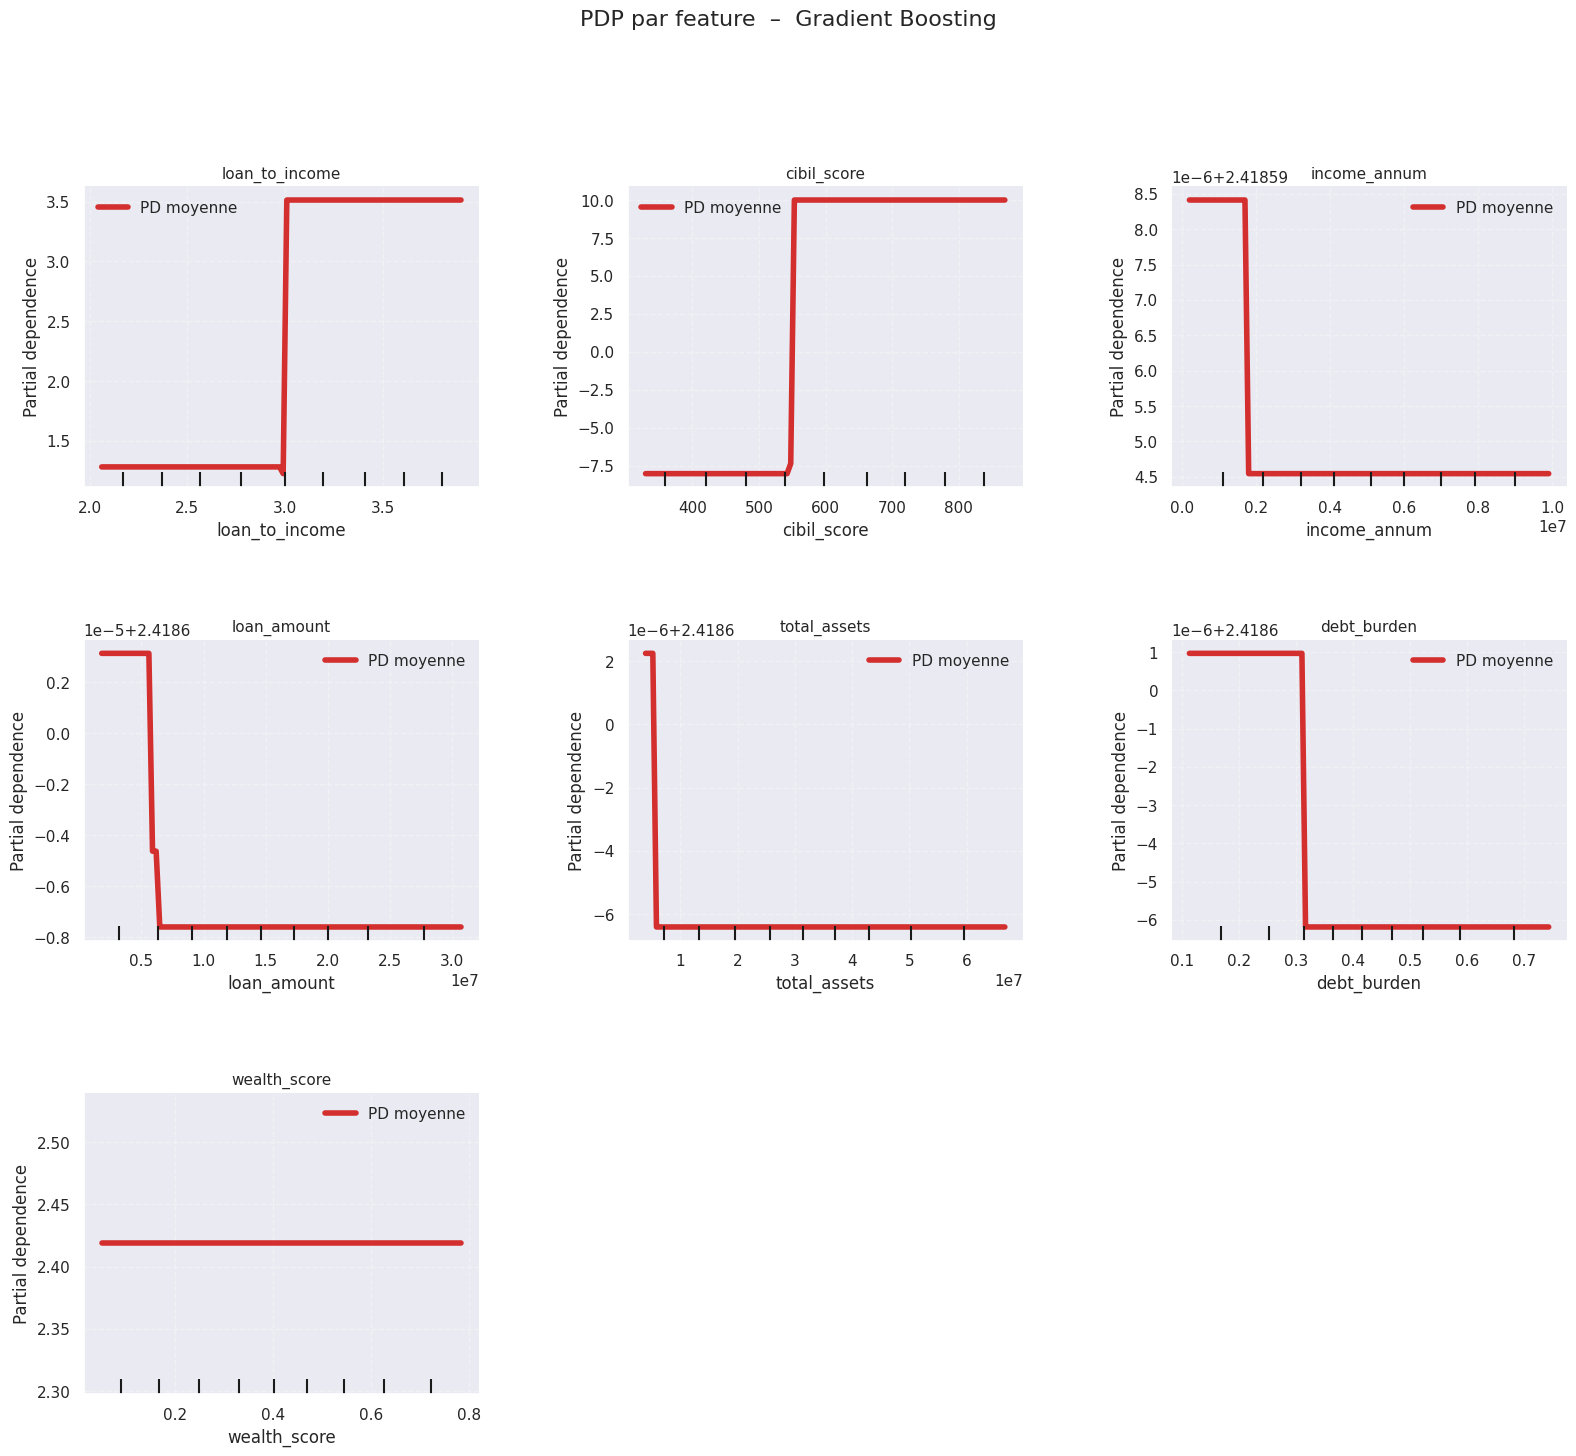

In [42]:
if 'PDP' in xai_methods:
    Printer.subsection("Partial Dependence Plots (PDP)")
    Printer.info("Effet marginal moyen de chaque feature sur la probabilité d'approbation.")

    features = ['loan_to_income', 'cibil_score', 'income_annum',
                'loan_amount', 'total_assets', 'debt_burden',
                'wealth_score']
    # Garder uniquement celles présentes dans X_train_final
    features = [f for f in features if f in X_train_final.columns]

    n_cols = 3
    n_rows = (len(features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(5.5 * n_cols, 4.8 * n_rows), sharey=False)
    axes_flat = np.array(axes).flatten()

    feat_names = list(X_train_final.columns)

    for i, feat in enumerate(features):
        feat_idx = feat_names.index(feat)
        PartialDependenceDisplay.from_estimator(
            best_model,
            best_Xtr,
            [feat_idx],
            kind='average',
            ax=axes_flat[i],
            ice_lines_kw={"color": "#cccccc", "alpha": 0.18, "lw": 0.7},
            line_kw={"color": "#d32f2f", "lw": 4, "label": "PD moyenne"},
            centered=False,
            subsample=1000,
            feature_names=feat_names,
        )
        axes_flat[i].set_title(feat, fontsize=11)
        axes_flat[i].grid(alpha=0.25)

    # Supprime les axes vides
    for j in range(len(features), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.suptitle(f"PDP par feature  –  {best_name}", fontsize=16, y=1.03)
    plt.tight_layout(pad=2.8, w_pad=4.5, h_pad=4.8)
    # ou fig.subplots_adjust(wspace=0.38, hspace=0.48) si tu veux ajuster finement
    fig.savefig("/kaggle/working/pdp.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("PDP skipped – retire 'PDP' de xai_methods pour le désactiver")

## 11.2 Permutation Feature Importance (PFI)


Permutation Feature Importance
  ℹ  Chute du ROC-AUC quand on permute aléatoirement chaque feature (10 répétitions).


,feature,importance,std
6,cibil_score,0.5040,±0.0133
5,loan_term,0.0149,±0.0011
13,assets_to_loan,0.0078,±0.0007
11,loan_to_income,0.0020,±0.0003
1,education,0.0000,±0.0000
4,loan_amount,0.0000,±0.0000
3,income_annum,0.0000,±0.0000
2,self_employed,0.0000,±0.0000
7,residential_assets_value,0.0000,±0.0000
8,commercial_assets_value,0.0000,±0.0000


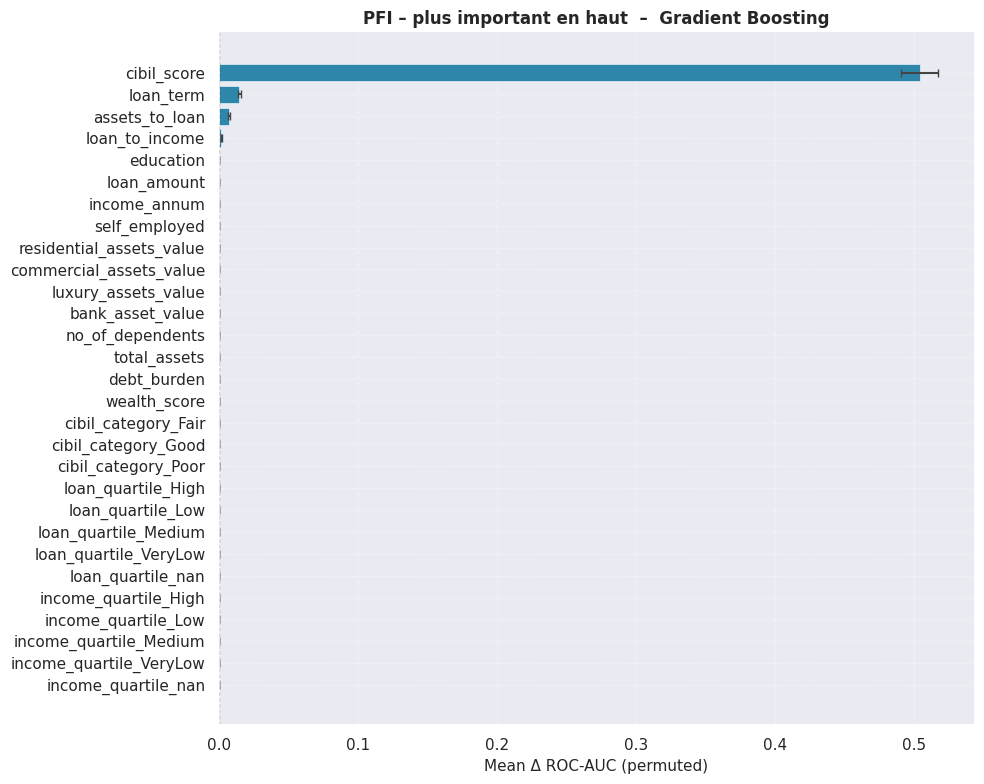

In [43]:
if 'PFI' in xai_methods:
    print("\nPermutation Feature Importance")
    Printer.info("Chute du ROC-AUC quand on permute aléatoirement chaque feature (10 répétitions).")

    pfi = permutation_importance(
        best_model, best_Xte, y_test,
        n_repeats=10, random_state=42, scoring='roc_auc'
    )
    feat_names_list = list(X_train_final.columns)
    imp = pd.DataFrame({
        'feature':    feat_names_list,
        'importance': pfi.importances_mean,
        'std':        pfi.importances_std,
    }).sort_values('importance', ascending=False)

    display(imp.head(15).style
            .background_gradient(subset=['importance'], cmap='Blues')
            .format({'importance': '{:.4f}', 'std': '±{:.4f}'})
            .set_caption(f"PFI – {best_name}"))

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(imp['feature'][::-1], imp['importance'][::-1],
            xerr=imp['std'][::-1], color='#2E86AB',
            ecolor='#444', capsize=3, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Mean Δ ROC-AUC (permuted)', fontsize=11)
    ax.set_title(f"PFI – plus important en haut  –  {best_name}", fontweight='bold')
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    fig.savefig("/kaggle/working/pfi.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("PFI skipped")

## 11.3 SHAP Values


  ── SHAP Values ────────────────────────────────────────────
  ℹ  Valeurs de Shapley – contribution individuelle de chaque feature à chaque prédiction.

SHAP summary plot  (importance globale – bar)


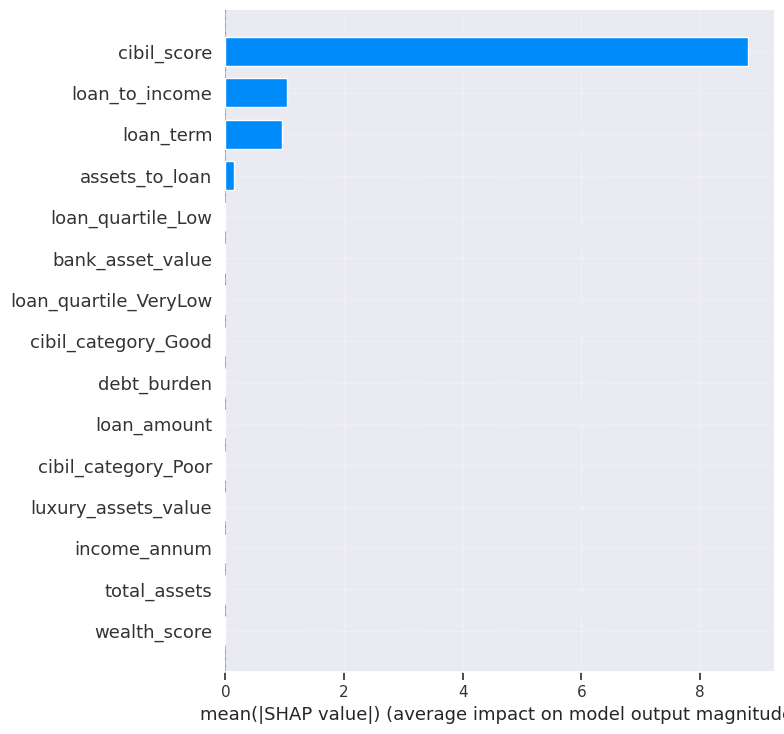


SHAP Beeswarm plot  (direction + magnitude)


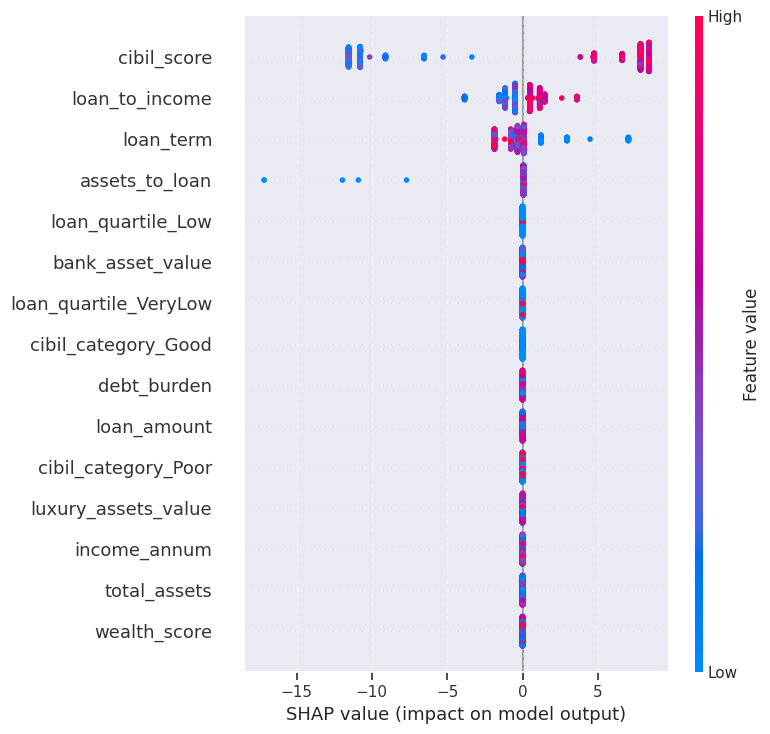


SHAP Waterfall – explication individuelle (observation 0)


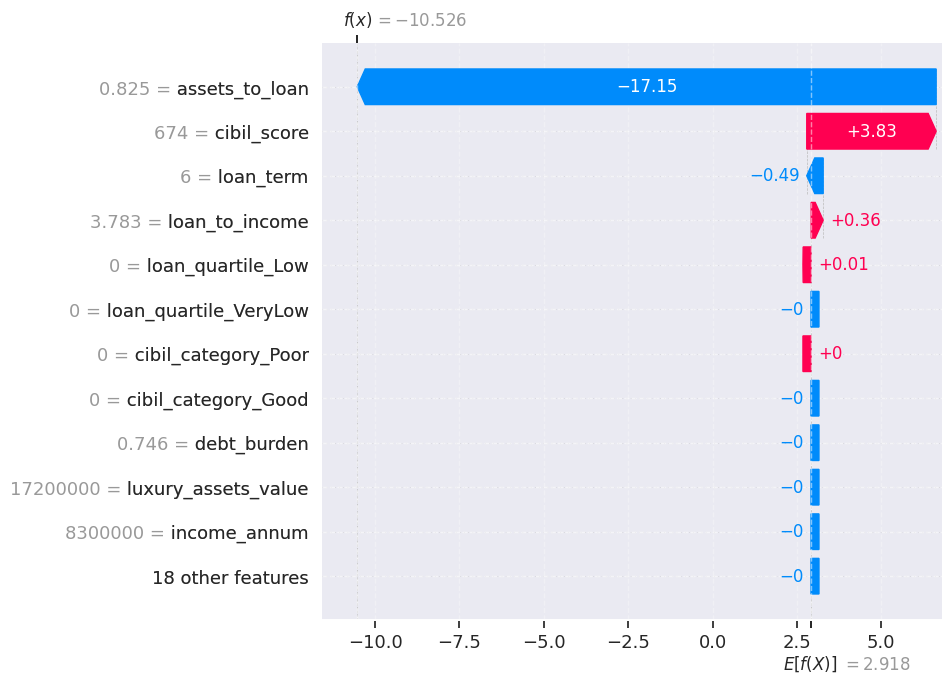

In [38]:
if 'SHAP' in xai_methods:
    Printer.subsection("SHAP Values")
    Printer.info("Valeurs de Shapley – contribution individuelle de chaque feature à chaque prédiction.")

    is_tree = any(n in best_name for n in ('Random Forest','XGBoost','Gradient Boosting'))

    if is_tree:
        explainer = shap.TreeExplainer(best_model)
        shap_vals = explainer.shap_values(X_test_final)
    else:
        # KernelExplainer pour LR / SVM (plus lent – sous-échantillon 200 lignes)
        background = shap.kmeans(best_Xtr, 50)
        explainer  = shap.KernelExplainer(best_model.predict_proba, background)
        shap_vals  = explainer.shap_values(best_Xte[:200], nsamples=80)
        Xtest_shap = (pd.DataFrame(best_Xte[:200], columns=X_train_final.columns)
                      if not isinstance(best_Xte, pd.DataFrame)
                      else best_Xte.iloc[:200])

    # ── Robust extraction of class-1 SHAP values ─────────────────────────────
    # scikit-learn RF (new SHAP): shap_values → ndarray (n, features, 2)
    # XGBoost / GBDT             shap_values → ndarray (n, features)   OR list[2]
    sv_arr = np.array(shap_vals)
    if sv_arr.ndim == 3:
        # shape (n_samples, n_features, n_classes) → take class 1
        sv1 = sv_arr[:, :, 1]
    elif isinstance(shap_vals, list) and len(shap_vals) == 2:
        # list[class0_array, class1_array]
        sv1 = np.array(shap_vals[1])
    else:
        # already (n_samples, n_features)
        sv1 = sv_arr

    if is_tree:
        Xtest_shap = X_test_final

    # ── Robust extraction of base value ──────────────────────────────────────
    ev = np.array(explainer.expected_value)
    if ev.ndim == 0:
        base_val = float(ev)
    elif ev.shape[0] >= 2:
        base_val = float(ev[1])
    else:
        base_val = float(ev[0])

    # ── SHAP Summary plot – bar (importance globale) ──────────────────────────
    print("\nSHAP summary plot  (importance globale – bar)")
    shap.summary_plot(sv1, Xtest_shap, plot_type='bar', max_display=15, show=True)

    # ── SHAP Beeswarm (direction + magnitude) ────────────────────────────────
    print("\nSHAP Beeswarm plot  (direction + magnitude)")
    shap.summary_plot(sv1, Xtest_shap, max_display=15, show=True)

    # ── Waterfall pour la 1ère observation ───────────────────────────────────
    print("\nSHAP Waterfall – explication individuelle (observation 0)")
    exp = shap.Explanation(
        values     = sv1[0],
        base_values= base_val,
        data       = np.array(Xtest_shap.iloc[0]),
        feature_names = list(X_train_final.columns),
    )
    shap.waterfall_plot(exp, max_display=12, show=True)

else:
    print("SHAP skipped")


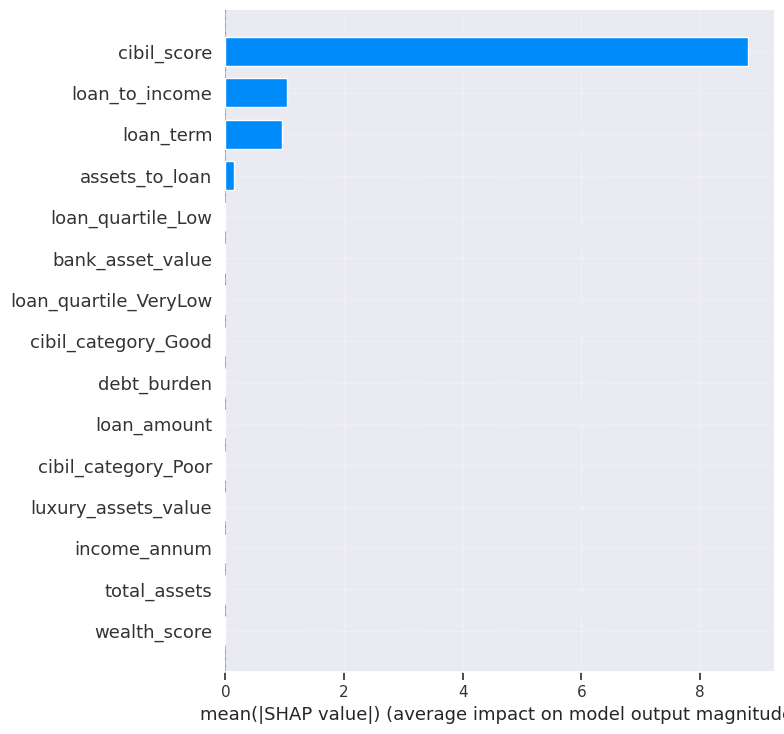

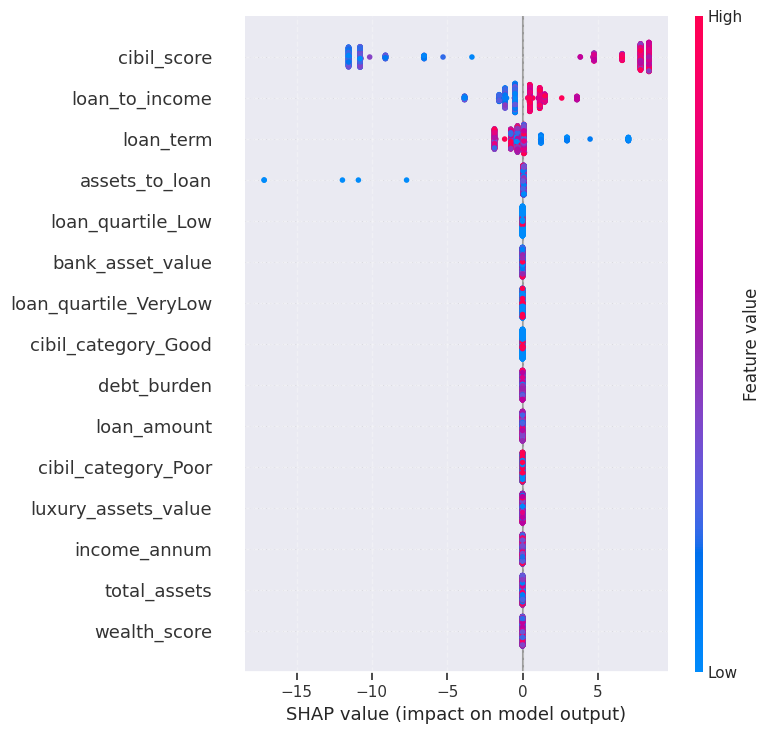

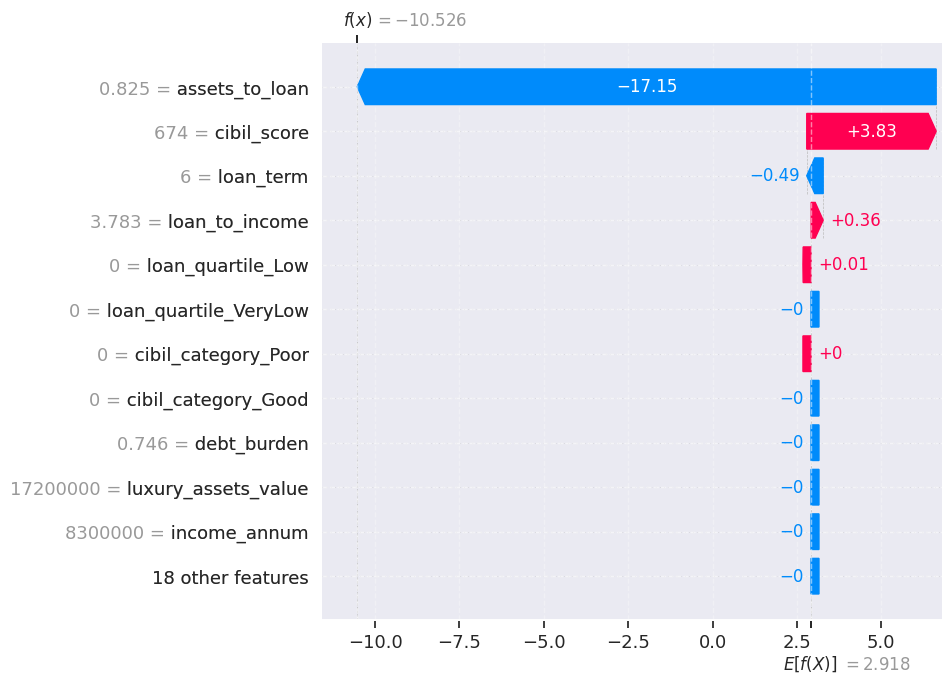

In [44]:
# SHAP BAR
shap.summary_plot(sv1, Xtest_shap, plot_type='bar', max_display=15, show=False)
plt.savefig("/kaggle/working/shap_bar.png", dpi=300, bbox_inches='tight')
plt.show()

# SHAP BEESWARM
shap.summary_plot(sv1, Xtest_shap, max_display=15, show=False)
plt.savefig("/kaggle/working/shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

# SHAP WATERFALL
shap.waterfall_plot(exp, max_display=12, show=False)
plt.savefig("/kaggle/working/shap_waterfall.png", dpi=300, bbox_inches='tight')
plt.show()


## 11.4 Sauvegarde des artefacts (pour Streamlit)

In [39]:
import joblib, json, os

SAVE_DIR = '/kaggle/working/model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Meilleur modèle + scaler + encodeurs
joblib.dump(best_model, f'{SAVE_DIR}/best_model.pkl')
joblib.dump(scaler,     f'{SAVE_DIR}/scaler.pkl')
joblib.dump({'le_edu': le_edu, 'le_self': le_self, 'ohe': ohe},
            f'{SAVE_DIR}/encoders.pkl')

# Config JSON (utilisé par predictor.py dans l'app Streamlit)
feature_config = {
    "feature_names":      list(X_train_final.columns),
    "original_features":  original_features,
    "loan_max":           float(loan_max_train),
    "dep_max":            float(dep_max_train),
    "income_max":         float(income_max_train),
    "loan_bins":          [float(v) for v in loan_bins],
    "income_bins":        [float(v) for v in income_bins],
    "scaled":             best_name in ('Logistic Regression', 'SVM'),
    "best_model_name":    best_name,
    "model_performances": {n: {"acc":  float(r['accuracy']),
                               "f1":   float(r['f1']),
                               "roc":  float(r['roc_auc']),
                               "prec": float(r['precision']),
                               "rec":  float(r['recall'])}
                           for n, r in results.items()},
}
with open(f'{SAVE_DIR}/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

Printer.success(f"Artefacts sauvegardés dans {SAVE_DIR}/")
Printer.metric("Fichiers créés", os.listdir(SAVE_DIR))

  ✅ Artefacts sauvegardés dans /kaggle/working/model/
  📊 Fichiers créés                      ['best_model.pkl', 'scaler.pkl', 'encoders.pkl', 'feature_config.json']
